In [134]:
!pip install rdkit-pypi
!pip install scipy
!pip install py3Dmol


In [117]:
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd
import numpy as np

In [118]:
# from rdkit import Chem
# from rdkit.Chem import AllChem

# mol = Chem.MolFromSmiles('CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H](C3=CC=C(C=C3)O)N)C(=O)O)C')

# # Get fingerprint WITH bit information
# info = {}
# fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024, bitInfo=info)

# # info now contains: {bit_index: [(atom_idx, radius), ...]}
# # This tells you which atom and at what radius each bit was set

# # Example: Find what atoms/substructures activate bit 100
# if 1 in info:
#     for atom_idx, radius in info[1]:
#         print(f"Bit 100 set by atom {atom_idx} at radius {radius}")
#         print(f"Atom type: {mol.GetAtomWithIdx(atom_idx).GetSymbol()}")

# info

In [119]:
df = pd.read_csv("morgan_fingerprints_targets_progress.csv")
df = df.dropna(subset=['smiles'])
df = df[df['name']!= '[]']
df['smiles'] = df['smiles'].apply(lambda x: x[2:-2])
df

,Unnamed: 0,Cpd,Formula,RT,Mass,CAS_ID,Source,Score,Algorithm,RunName,name,smiles
0,0,3601,C16H19N3O5S,4.749,365.1046,NaN,FBF,91.56,FBF,bigmed,"['(2S,5R,6R)-6-[[(2R)-2-amino-2-(4-hydroxyphen...",CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H]...
1,1,1637,C64H117NO10,20.107,1059.8758,NaN,FBF,91.27,FBF,bigmed,"['[4,5-dihydroxy-2-[(E)-3-hydroxy-2-[[(13Z,16Z...",CCCCCCCCCCC/C=C/C(C(COC1C(C(C(C(O1)CO)O)O)OC(=...
2,2,1860,C31H55NO7,5.399,553.3978,NaN,FBF,90.28,FBF,bigmed,"['(3R,5R)-7-[(1S,2S,6S,8S,8aR)-6-hydroxy-2-met...",CC[C@H](C)C(=O)O[C@H]1C[C@@H](C=C2[C@H]1[C@H](...
4,4,3635,C7H11N5O,3.763,181.0965,NaN,FBF,86.70,FBF,bigmed,"['2-amino-6-methyl-5,6,7,8-tetrahydro-3H-pteri...",CC1CNC2=C(N1)C(=O)NC(=N2)N
5,5,3462,C12H23N3O5S2,10.284,353.1085,NaN,FBF,86.64,FBF,bigmed,"['(2R,5S)-2,5-diamino-3-[[(2R)-2-amino-2-carbo...",CC(C)C[C@@H](C(=O)C([C@@H](C(=O)O)N)SSC[C@@H](...
...,...,...,...,...,...,...,...,...,...,...,...,...
195,195,251,C8H6O5,0.435,182.0209,NaN,FBF,80.84,FBF,tiny,"['5-hydroxybenzene-1,3-dicarboxylic acid']",C1=C(C=C(C=C1C(=O)O)O)C(=O)O
196,196,5909,C7H14S2,1.396,162.0525,NaN,FBF,80.74,FBF,tiny,['2-[[(E)-prop-1-enyl]disulfanyl]butane'],CCC(C)SS/C=C/C
197,197,3013,C27H46O10,5.192,530.3104,NaN,FBF,80.73,FBF,tiny,"['(3R,5S,6S,7R,8S,9R,12R,13R,14S,15R)-6,14-dih...",C[C@H]1C[C@@]2(CO2)C(=O)[C@@H]([C@H]([C@H]([C@...
198,198,445,C8H17NO2,0.383,159.1273,NaN,FBF,80.42,FBF,tiny,['(3S)-3-(aminomethyl)-5-methylhexanoic acid'],CC(C)C[C@@H](CC(=O)O)CN


In [120]:
# Convert to RDKit molecules
mols = [Chem.MolFromSmiles(s) for s in df['smiles']]

# Compute Morgan fingerprints
fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=1024) for m in mols]

# Convert to numpy array (optional, for ML)
fps_array = np.array([np.frombuffer(fp.ToBitString().encode('utf-8'), 'u1') - ord('0') for fp in fps])
fps_array

[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not removing hydrogen atom without neighbors
[15:38:04] WARNING: not r

array([[0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [121]:
top_words = pd.read_csv('top_words_from_the_pearl.txt', delimiter='\t')
top_words

,word,frequency
0,the,2187
1,and,1599
2,of,612
3,a,610
4,he,597
...,...,...
1019,burning,3
1020,hide,3
1021,dried,3
1022,sandy,3


In [122]:
column_populations = fps_array.sum(axis=0)
sorted_column_indices = np.argsort(column_populations)[::-1]
sorted_column_indices

array([807,  33, 650, ..., 439, 685, 581])

In [123]:

def row_to_words(row):
    """Get the top N words for a given row based on column population order"""
    # Get indices where this row has 1s
    active_columns = np.where(row == 1)[0]
    print(active_columns)
    # Map to words and sort by column population
    words_with_col= [(top_words.iloc[col]['word'], col) for col in active_columns]
    print(words_with_col)
    # words_with_pop.sort(key=lambda x: x[1], reverse=True)
    return words_with_col


In [135]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

def molecule_with_word_overlay(smiles, words, figsize=(12, 10)):
    """
    Overlay words onto a molecular structure
    words: list of (word, bit_idx) tuples to place on the molecule
    """
    mol = Chem.MolFromSmiles(smiles)
    
    # Generate 2D coordinates
    AllChem.Compute2DCoords(mol)
    
    # Get atom positions
    conf = mol.GetConformer()
    atom_positions = []
    for i in range(mol.GetNumAtoms()):
        pos = conf.GetAtomPosition(i)
        atom_positions.append((pos.x, pos.y))
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Draw the molecule structure first
    img = Draw.MolToImage(mol, size=(800, 800))
    
    # Get the bounds for proper scaling
    positions = np.array(atom_positions)
    x_min, y_min = positions.min(axis=0)
    x_max, y_max = positions.max(axis=0)
    
    # Display molecule as background
    ax.imshow(img, extent=[x_min-1, x_max+1, y_min-1, y_max+1], alpha=0.3, zorder=0)
    
    # Get bit info for this molecule
    info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024, bitInfo=info)
    
    # Place words at their corresponding atom positions
    placed_positions = []
    for word, bit_idx in words:
        if bit_idx in info:
            atom_idx, radius = info[bit_idx][0]  # Get first occurrence
            x, y = atom_positions[atom_idx]
            
            # Add some jitter if positions overlap
            offset_x, offset_y = 0, 0
            for px, py in placed_positions:
                if abs(px - x) < 0.5 and abs(py - y) < 0.5:
                    offset_x += 0.3
                    offset_y += 0.3
            
            x += offset_x
            y += offset_y
            placed_positions.append((x, y))
            
            # Draw word
            ax.text(x, y, word, fontsize=10, ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                            edgecolor='blue', alpha=0.7),
                   zorder=2)
            
            # Optional: draw a line from word to atom
            ax.plot([atom_positions[atom_idx][0], x], 
                   [atom_positions[atom_idx][1], y], 
                   'b-', alpha=0.3, linewidth=0.5, zorder=1)
    
    ax.set_xlim(x_min-1.5, x_max+1.5)
    ax.set_ylim(y_min-1.5, y_max+1.5)
    ax.axis('off')
    ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig

CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H](C3=CC=C(C=C3)O)N)C(=O)O)C
[   1    5   18   33   36  125  126  128  130  147  181  233  250  251
  255  274  289  314  341  356  362  387  389  407  573  578  585  607
  611  650  673  675  697  709  726  745  753  754  786  807  829  849
  893  913  919  935 1019]
[('and', 1), ('his', 5), ('had', 18), ('eyes', 33), ('you', 36), ('family', 125), ('fire', 126), ('black', 128), ('door', 130), ('watched', 147), ('air', 181), ('blanket', 233), ('dealer', 250), ('still', 251), ('slipped', 255), ('secret', 274), ('almost', 289), ('cave', 314), ('price', 341), ('followed', 356), ('many', 362), ('nose', 387), ('waves', 389), ('warm', 407), ('together', 573), ('yes', 578), ('disappeared', 585), ('school', 607), ('desert', 611), ('arranged', 650), ('death', 673), ('boy', 675), ('silver', 697), ('paper', 709), ('continued', 726), ('below', 745), ('faces', 753), ('whisper', 754), ('fool', 786), ('pools', 807), ('pile', 829), ('laughed', 849), ('althou

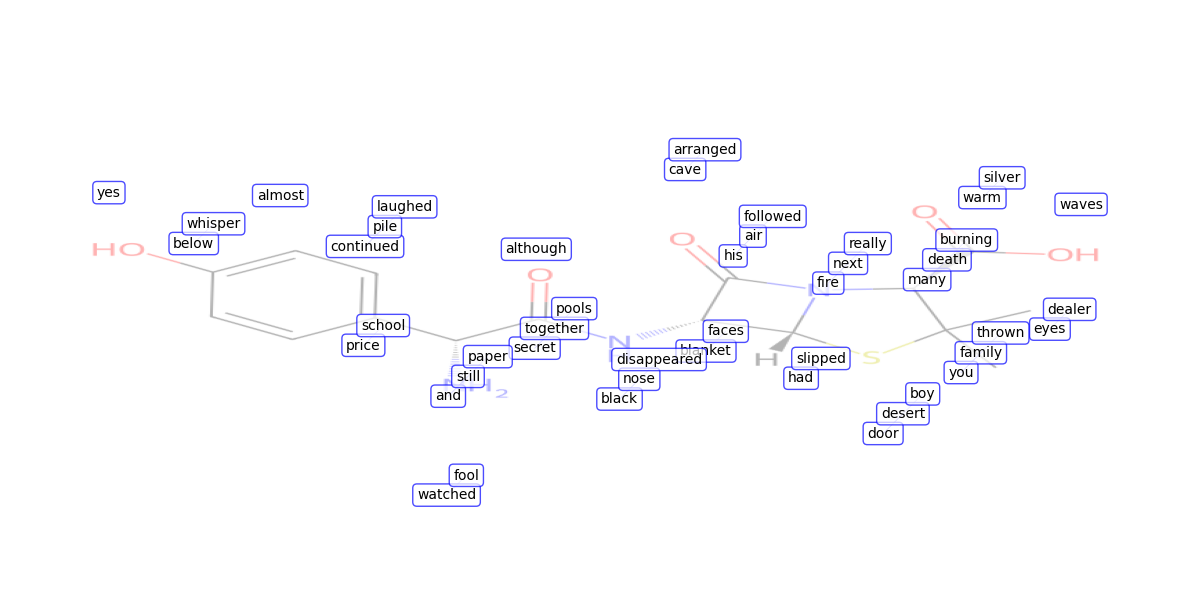

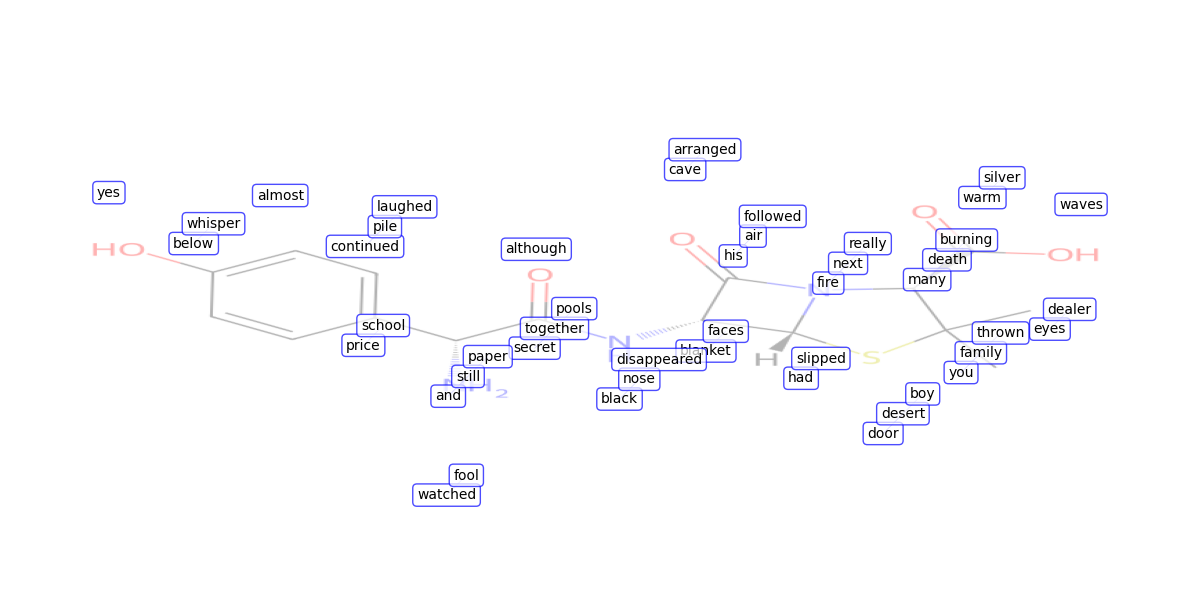

In [144]:
index = 0
print(df.iloc[index]['smiles'])
molecule_with_word_overlay(df.iloc[index]['smiles'], row_to_words(fps_array[index]))


In [166]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

def create_py3dmol_word_cloud(smiles, words_to_embed, 
                               width=800, height=800,
                               surface_opacity=0.3,
                               surface_color='lightblue',
                               stick_radius=0.15,
                               sphere_scale=0.3,
                               label_fontsize=14,
                               label_color='navy',
                               show_surface=True,
                               style='ball_and_stick'):
    """
    Create an interactive 3D molecular visualization with word labels using Py3Dmol
    
    Parameters:
    -----------
    smiles : str
        SMILES string of molecule
    words_to_embed : list of (word, bit_idx) tuples
        Words to place as labels on the molecule
    width : int
        Width of viewer in pixels
    height : int
        Height of viewer in pixels
    surface_opacity : float
        Transparency of electron cloud surface (0-1)
    surface_color : str
        Color of the surface
    stick_radius : float
        Radius of bond sticks
    sphere_scale : float
        Scale of atom spheres
    label_fontsize : int
        Font size for word labels
    label_color : str
        Color of word labels
    show_surface : bool
        Whether to show electron density surface
    style : str
        'ball_and_stick', 'stick', 'sphere', or 'cartoon'
    
    Returns:
    --------
    view : py3Dmol.view
        Interactive 3D viewer object
    """
    
    # Prepare molecule
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    
    # Add hydrogens and generate 3D coordinates
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)
    
    # Convert to mol block for py3Dmol
    mol_block = Chem.MolToMolBlock(mol)
    
    # Create viewer
    view = py3Dmol.view(width=width, height=height)
    view.addModel(mol_block, 'mol')
    
    # Set background
    view.setBackgroundColor('white')
    
    # Apply molecular style
    if style == 'ball_and_stick':
        view.setStyle({'stick': {'radius': stick_radius, 'color': 'black'},
                       'sphere': {'scale': sphere_scale, 'color': 'white'}})
    elif style == 'stick':
        view.setStyle({'stick': {'radius': stick_radius, 'color': 'black'}})
    elif style == 'sphere':
        view.setStyle({'sphere': {'scale': 0.5, 'colorscheme': 'Jmol'}})
    elif style == 'cartoon':
        view.setStyle({'stick': {'colorscheme': 'Jmol'}})
    
    # Add electron cloud surface
    if show_surface:
        view.addSurface(py3Dmol.VDW, 
                       {'opacity': surface_opacity, 
                        'color': surface_color})
    
    # Get fingerprint info to map bits to atoms
    info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024, bitInfo=info)
    
    # Get conformer for atom positions
    conf = mol.GetConformer()
    
    # Calculate molecule center for offsetting labels
    atom_positions = []
    for i in range(mol.GetNumAtoms()):
        pos = conf.GetAtomPosition(i)
        atom_positions.append([pos.x, pos.y, pos.z])
    atom_positions = np.array(atom_positions)
    center = atom_positions.mean(axis=0)
    
    # Add word labels
    placed_words = set()  # Track to avoid duplicates
    
    for word, bit_idx in words_to_embed:
        if bit_idx in info and word not in placed_words:
            # Get the atom index this bit corresponds to
            atom_idx, radius = info[bit_idx][0]  # Take first occurrence
            
            # Skip hydrogens for cleaner visualization
            if mol.GetAtomWithIdx(atom_idx).GetSymbol() == 'H':
                continue
            
            # Get atom position
            pos = conf.GetAtomPosition(atom_idx)
            
            # Offset label outward from molecule center
            direction = np.array([pos.x, pos.y, pos.z]) - center
            direction = direction / (np.linalg.norm(direction) + 0.001)
            offset = direction * 2.0  # Offset distance
            
            label_pos = {
                'x': pos.x + offset[0],
                'y': pos.y + offset[1],
                'z': pos.z + offset[2]
            }
            
            # Add label
            view.addLabel(word, {
                'position': label_pos,
                'fontSize': label_fontsize,
                'fontColor': label_color,
                'backgroundColor': 'white',
                'backgroundOpacity': 0.7,
                'borderColor': label_color,
                'borderThickness': 1,
                'borderOpacity': 0.8,
                'alignment': 'center'
            })
            
            placed_words.add(word)
    
    # Set camera
    view.zoomTo()
    
    return view


# Convenience function to work with your fps_array
def create_word_molecule_art_py3dmol(row_idx, fps_array, smiles_list, 
                                      column_to_word, top_n=20, **kwargs):
    """
    Create Py3Dmol visualization for a specific molecule from your dataset
    
    Parameters:
    -----------
    row_idx : int
        Index of molecule in fps_array
    fps_array : numpy array
        Your fingerprint bit array
    smiles_list : list
        List of SMILES strings
    column_to_word : dict
        Mapping from column/bit index to words
    top_n : int
        Number of top words to display
    **kwargs : dict
        Additional arguments to pass to create_py3dmol_word_cloud
    
    Returns:
    --------
    view : py3Dmol.view
        Interactive 3D viewer
    """
    
    # Get the molecule
    smiles = smiles_list[row_idx]
    
    # Get active bits for this molecule
    active_bits = np.where(fps_array[row_idx] == 1)[0]
    
    # Get column populations
    column_populations = fps_array.sum(axis=0)
    
    # Sort active bits by population and take top N
    active_bits_sorted = sorted(active_bits, 
                               key=lambda x: column_populations[x], 
                               reverse=True)[:top_n]
    
    # Map to words
    words_to_embed = [(column_to_word[bit_idx], bit_idx) 
                      for bit_idx in active_bits_sorted
                      if bit_idx in column_to_word]
    
    # Create visualization
    return create_py3dmol_word_cloud(smiles, words_to_embed, **kwargs)



In [168]:
index = 0
print(df.iloc[index]['smiles'])
view =  create_py3dmol_word_cloud(df.iloc[index]['smiles'], row_to_words(fps_array[index]),
                                  surface_opacity=0.6,label_fontsize=12)

# view = create_py3dmol_word_cloud(smiles, words, 
#                                   width=1000, 
#                                   height=1000,
#                                   surface_opacity=0.25,
#                                   label_fontsize=16)
view.show()


CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H](C3=CC=C(C=C3)O)N)C(=O)O)C
[   1    5   18   33   36  125  126  128  130  147  181  233  250  251
  255  274  289  314  341  356  362  387  389  407  573  578  585  607
  611  650  673  675  697  709  726  745  753  754  786  807  829  849
  893  913  919  935 1019]
[('and', 1), ('his', 5), ('had', 18), ('eyes', 33), ('you', 36), ('family', 125), ('fire', 126), ('black', 128), ('door', 130), ('watched', 147), ('air', 181), ('blanket', 233), ('dealer', 250), ('still', 251), ('slipped', 255), ('secret', 274), ('almost', 289), ('cave', 314), ('price', 341), ('followed', 356), ('many', 362), ('nose', 387), ('waves', 389), ('warm', 407), ('together', 573), ('yes', 578), ('disappeared', 585), ('school', 607), ('desert', 611), ('arranged', 650), ('death', 673), ('boy', 675), ('silver', 697), ('paper', 709), ('continued', 726), ('below', 745), ('faces', 753), ('whisper', 754), ('fool', 786), ('pools', 807), ('pile', 829), ('laughed', 849), ('althou

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [157]:
def molecule_from_letter_bonds(smiles, words_to_embed):
    """
    Draw molecule where bonds are made of letters/words
    Most readable approach!
    """
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol)
    
    fig, ax = plt.subplots(figsize=(16, 16), facecolor='white')
    conf = mol.GetConformer()
    
    # Get fingerprint info
    info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 1024, bitInfo=info)
    
    # Map bits to words
    bit_to_word = {bit_idx: word for word, bit_idx in words_to_embed}
    
    # For each bond, try to assign a word
    bond_words = {}
    for bit_idx, word in bit_to_word.items():
        if bit_idx in info:
            atom_idx, rad = info[bit_idx][0]
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
            
            # Assign word to bonds in this environment
            for bond_idx in env:
                if bond_idx not in bond_words:  # First come, first served
                    bond_words[bond_idx] = word
                    break
    
    # Draw bonds as words
    for bond in mol.GetBonds():
        bond_idx = bond.GetIdx()
        begin_idx = bond.GetBeginAtomIdx()
        end_idx = bond.GetEndAtomIdx()
        
        p1 = conf.GetAtomPosition(begin_idx)
        p2 = conf.GetAtomPosition(end_idx)
        
        # Calculate angle for text rotation
        angle = np.degrees(np.arctan2(p2.y - p1.y, p2.x - p1.x))
        
        # Get word for this bond
        word = bond_words.get(bond_idx, '—')  # Default to dash
        
        # Calculate midpoint
        mid_x, mid_y = (p1.x + p2.x) / 2, (p1.y + p2.y) / 2
        
        # Draw word along bond
        ax.text(mid_x, mid_y, word,
               rotation=angle,
               rotation_mode='anchor',
               ha='center', va='center',
               fontsize=13, weight='bold',
               color='grey')
    
    # Draw atoms as small circles
    for i in range(mol.GetNumAtoms()):
        if mol.GetAtomWithIdx(i).GetSymbol() == 'H':
            continue
        pos = conf.GetAtomPosition(i)
        circle = plt.Circle((pos.x, pos.y), 0.1, color='grey', fill=False)
        ax.add_patch(circle)
    
    ax.axis('equal')
    ax.axis('off')
    plt.tight_layout()
    return fig

CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H](C3=CC=C(C=C3)O)N)C(=O)O)C
[   1    5   18   33   36  125  126  128  130  147  181  233  250  251
  255  274  289  314  341  356  362  387  389  407  573  578  585  607
  611  650  673  675  697  709  726  745  753  754  786  807  829  849
  893  913  919  935 1019]
[('and', 1), ('his', 5), ('had', 18), ('eyes', 33), ('you', 36), ('family', 125), ('fire', 126), ('black', 128), ('door', 130), ('watched', 147), ('air', 181), ('blanket', 233), ('dealer', 250), ('still', 251), ('slipped', 255), ('secret', 274), ('almost', 289), ('cave', 314), ('price', 341), ('followed', 356), ('many', 362), ('nose', 387), ('waves', 389), ('warm', 407), ('together', 573), ('yes', 578), ('disappeared', 585), ('school', 607), ('desert', 611), ('arranged', 650), ('death', 673), ('boy', 675), ('silver', 697), ('paper', 709), ('continued', 726), ('below', 745), ('faces', 753), ('whisper', 754), ('fool', 786), ('pools', 807), ('pile', 829), ('laughed', 849), ('althou

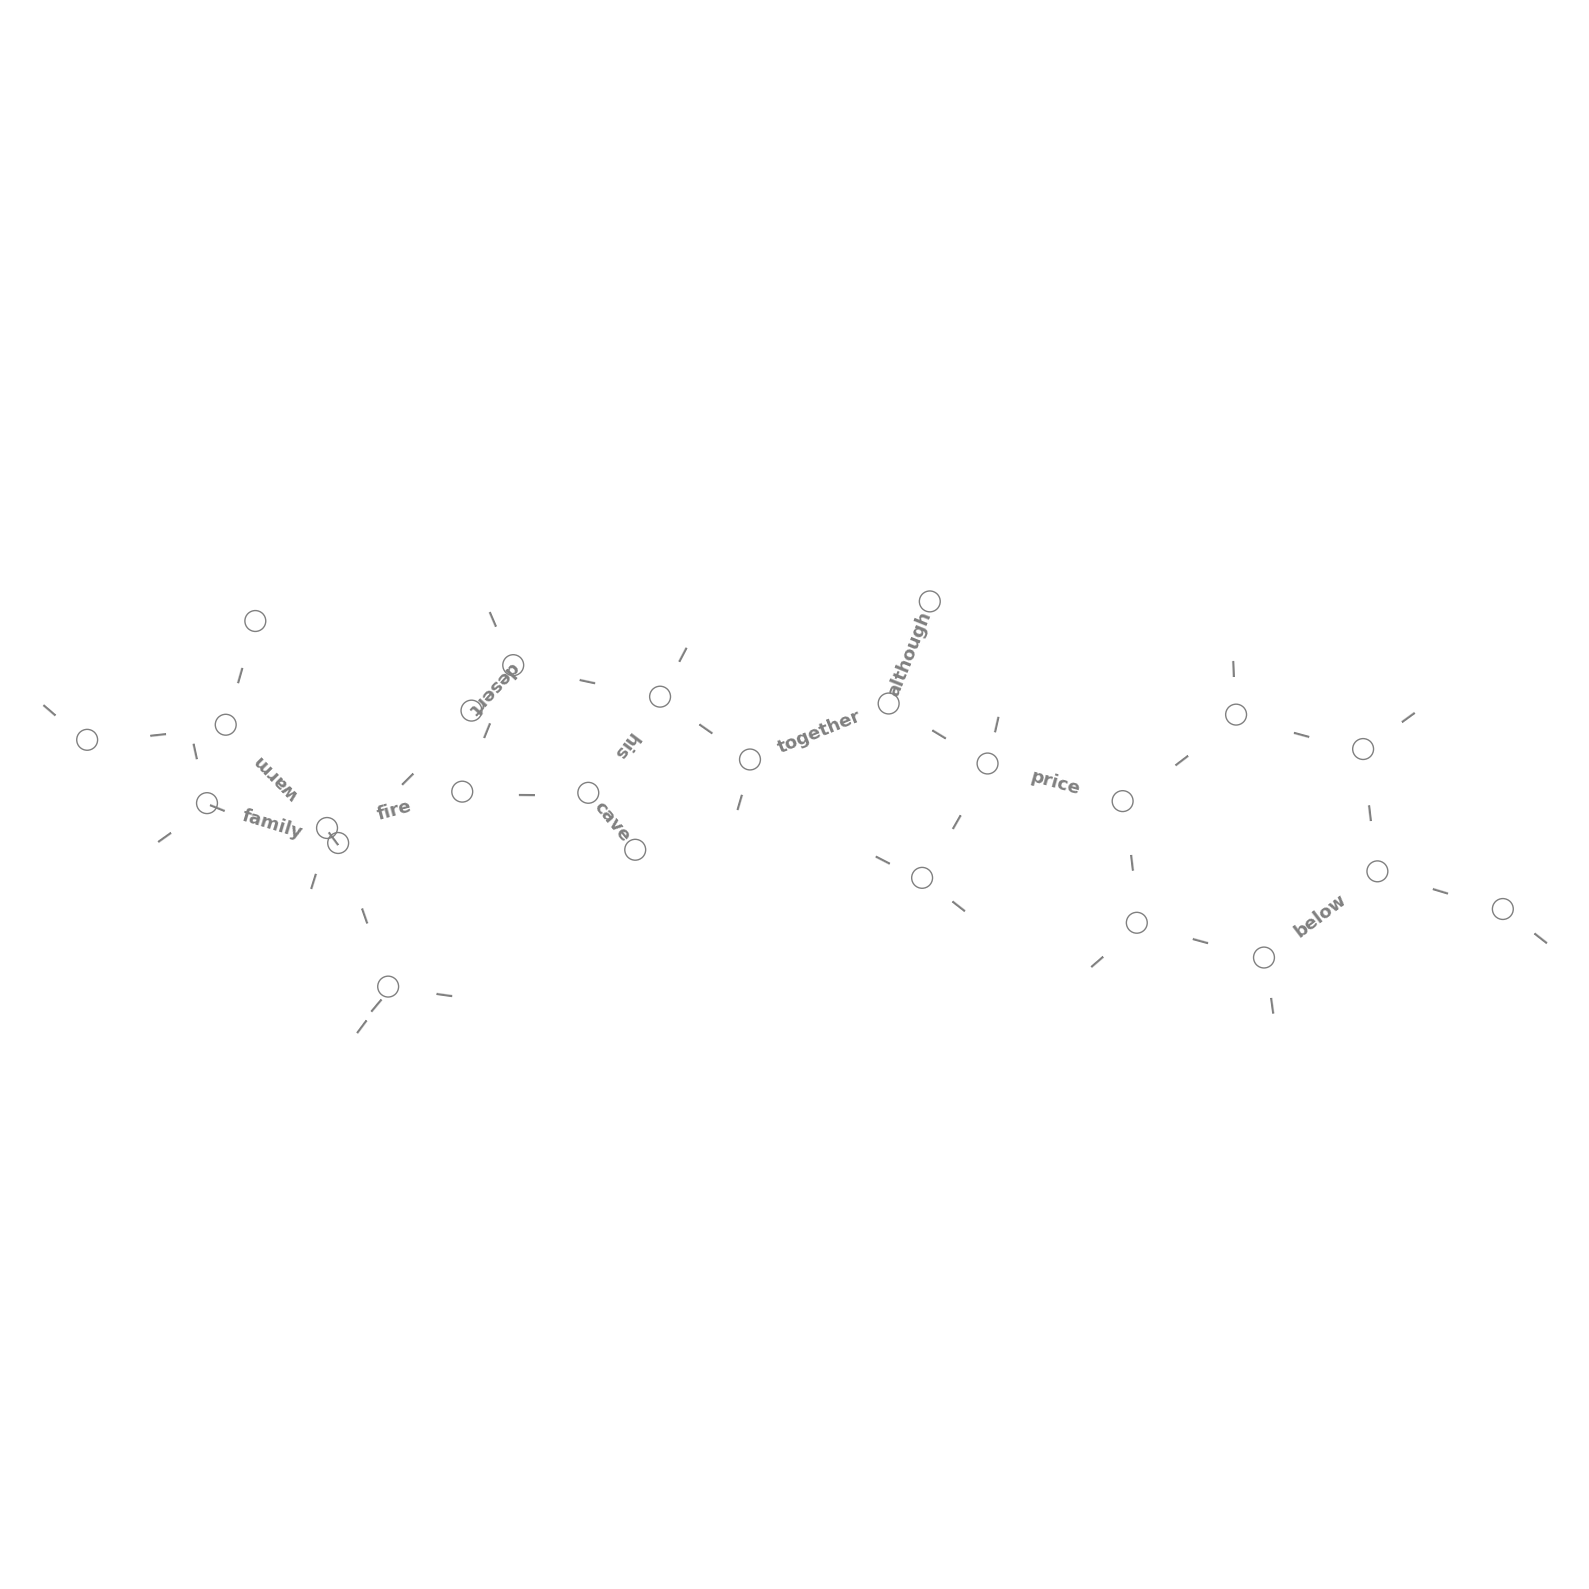

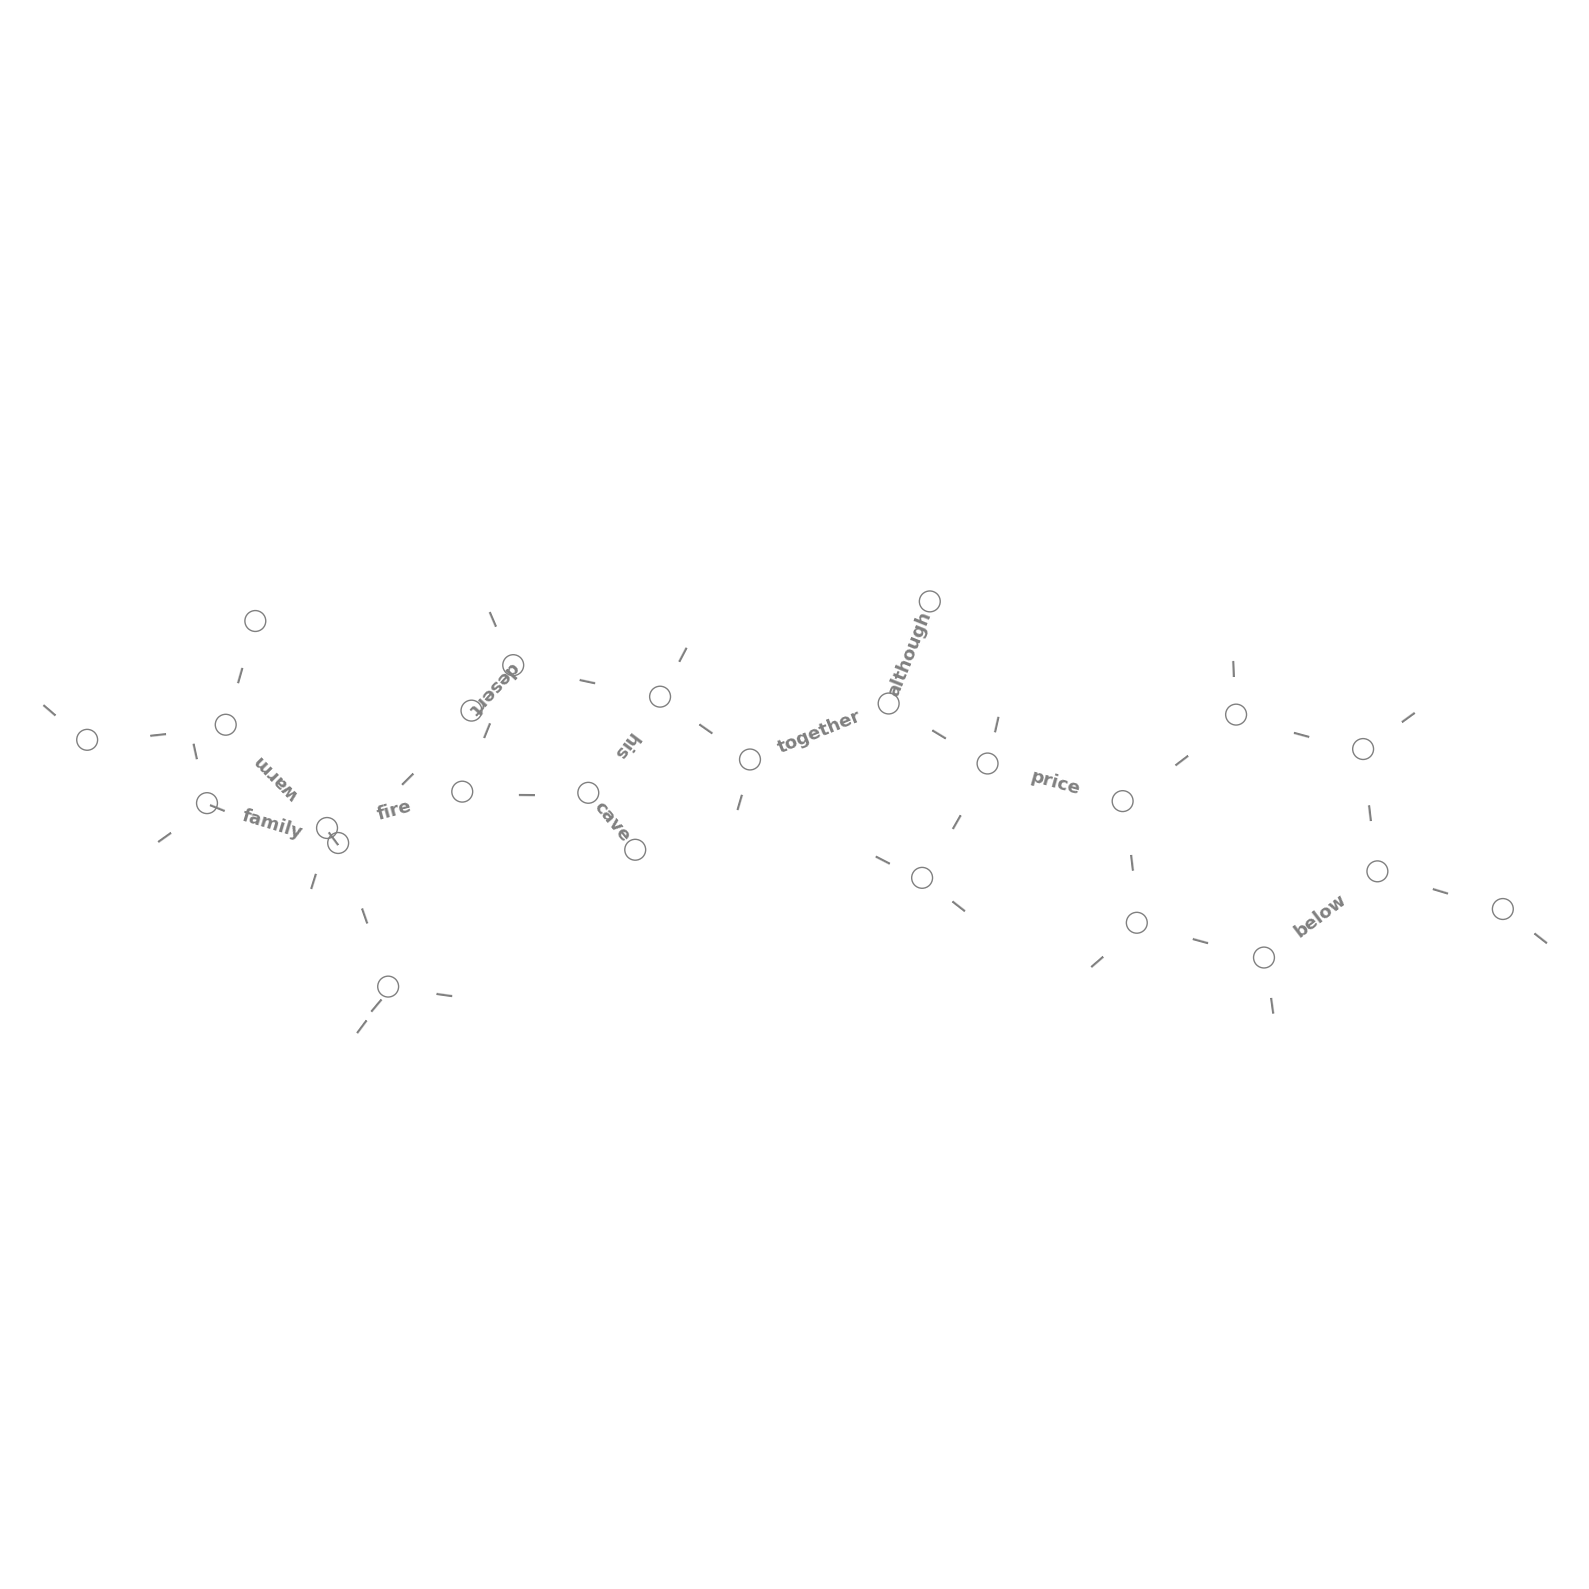

In [158]:
index = 0
print(df.iloc[index]['smiles'])
molecule_from_letter_bonds(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# view = create_py3dmol_word_cloud(smiles, words, 
#                                   width=1000, 
#                                   height=1000,
#                                   surface_opacity=0.25,
#                                   label_fontsize=16)


In [160]:
def clean_bond_label_molecule(smiles, words_to_embed, max_words=15):
    """
    Clean, readable: just label important bonds with words
    Like technical diagrams but poetic
    """
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol)
    AllChem.Compute2DCoords(mol)  # Force 2D for cleaner layout
    
    fig, ax = plt.subplots(figsize=(20, 20), facecolor='white')
    conf = mol.GetConformer()
    
    # Draw molecular skeleton cleanly
    for bond in mol.GetBonds():
        begin = bond.GetBeginAtomIdx()
        end = bond.GetEndAtomIdx()
        p1 = conf.GetAtomPosition(begin)
        p2 = conf.GetAtomPosition(end)
        
        ax.plot([p1.x, p2.x], [p1.y, p2.y], 
               'k-', linewidth=2, solid_capstyle='round')
    
    # Draw non-H atoms
    for i in range(mol.GetNumAtoms()):
        atom = mol.GetAtomWithIdx(i)
        if atom.GetSymbol() == 'H':
            continue
        pos = conf.GetAtomPosition(i)
        ax.plot(pos.x, pos.y, 'o', 
               markersize=15, color='black', 
               markerfacecolor='white', markeredgewidth=2)
    
    # Add word labels with leader lines
    info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 1024, bitInfo=info)
    
    placed_words = []
    for word, bit_idx in words_to_embed[:max_words]:
        if bit_idx in info:
            atom_idx = info[bit_idx][0][0]
            pos = conf.GetAtomPosition(atom_idx)
            
            # Offset label
            offset_x = 1.5 * (1 if len(placed_words) % 2 else -1)
            offset_y = 1.5 * np.sin(len(placed_words))
            
            label_x = pos.x + offset_x
            label_y = pos.y + offset_y
            
            # Leader line
            ax.plot([pos.x, label_x], [pos.y, label_y],
                   'k-', linewidth=0.5, alpha=0.3)
            
            # Word
            ax.text(label_x, label_y, word,
                   fontsize=14, style='italic',
                   ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.4',
                            facecolor='white',
                            edgecolor='none'))
            
            placed_words.append((label_x, label_y))
    
    ax.axis('equal')
    ax.axis('off')
    ax.margins(0.2)
    plt.tight_layout()
    return fig

CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H](C3=CC=C(C=C3)O)N)C(=O)O)C
[   1    5   18   33   36  125  126  128  130  147  181  233  250  251
  255  274  289  314  341  356  362  387  389  407  573  578  585  607
  611  650  673  675  697  709  726  745  753  754  786  807  829  849
  893  913  919  935 1019]
[('and', 1), ('his', 5), ('had', 18), ('eyes', 33), ('you', 36), ('family', 125), ('fire', 126), ('black', 128), ('door', 130), ('watched', 147), ('air', 181), ('blanket', 233), ('dealer', 250), ('still', 251), ('slipped', 255), ('secret', 274), ('almost', 289), ('cave', 314), ('price', 341), ('followed', 356), ('many', 362), ('nose', 387), ('waves', 389), ('warm', 407), ('together', 573), ('yes', 578), ('disappeared', 585), ('school', 607), ('desert', 611), ('arranged', 650), ('death', 673), ('boy', 675), ('silver', 697), ('paper', 709), ('continued', 726), ('below', 745), ('faces', 753), ('whisper', 754), ('fool', 786), ('pools', 807), ('pile', 829), ('laughed', 849), ('althou

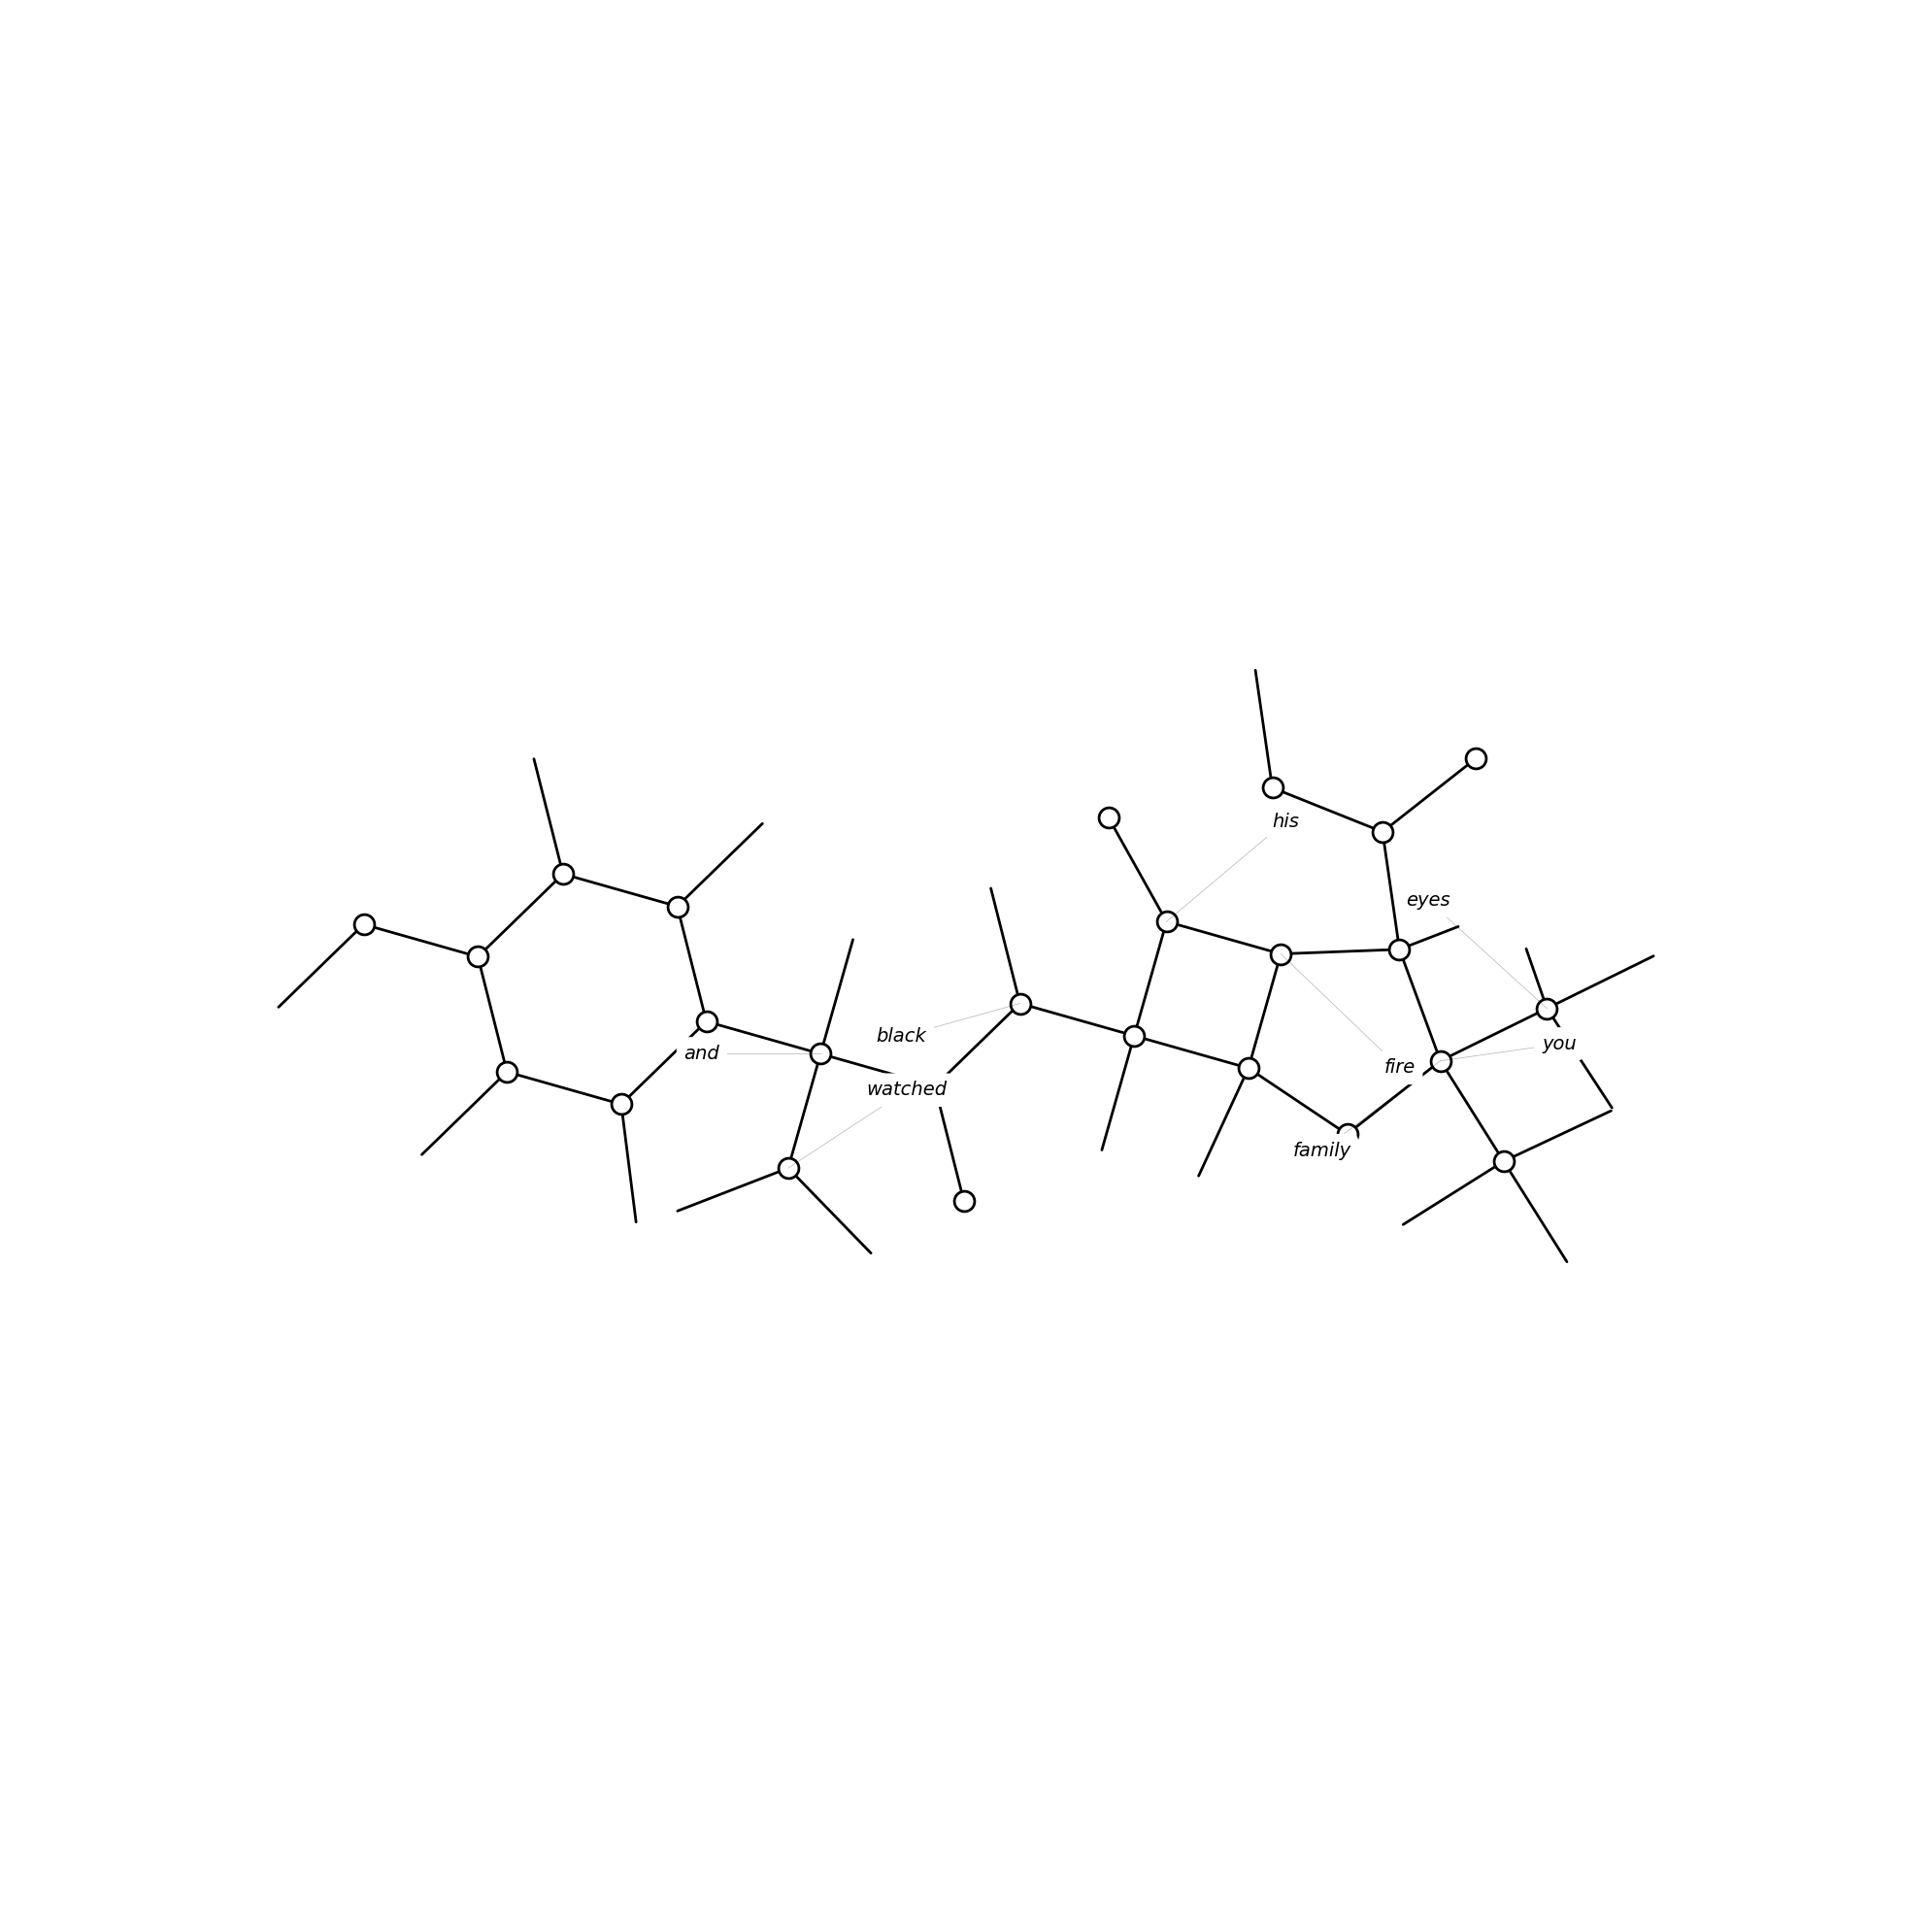

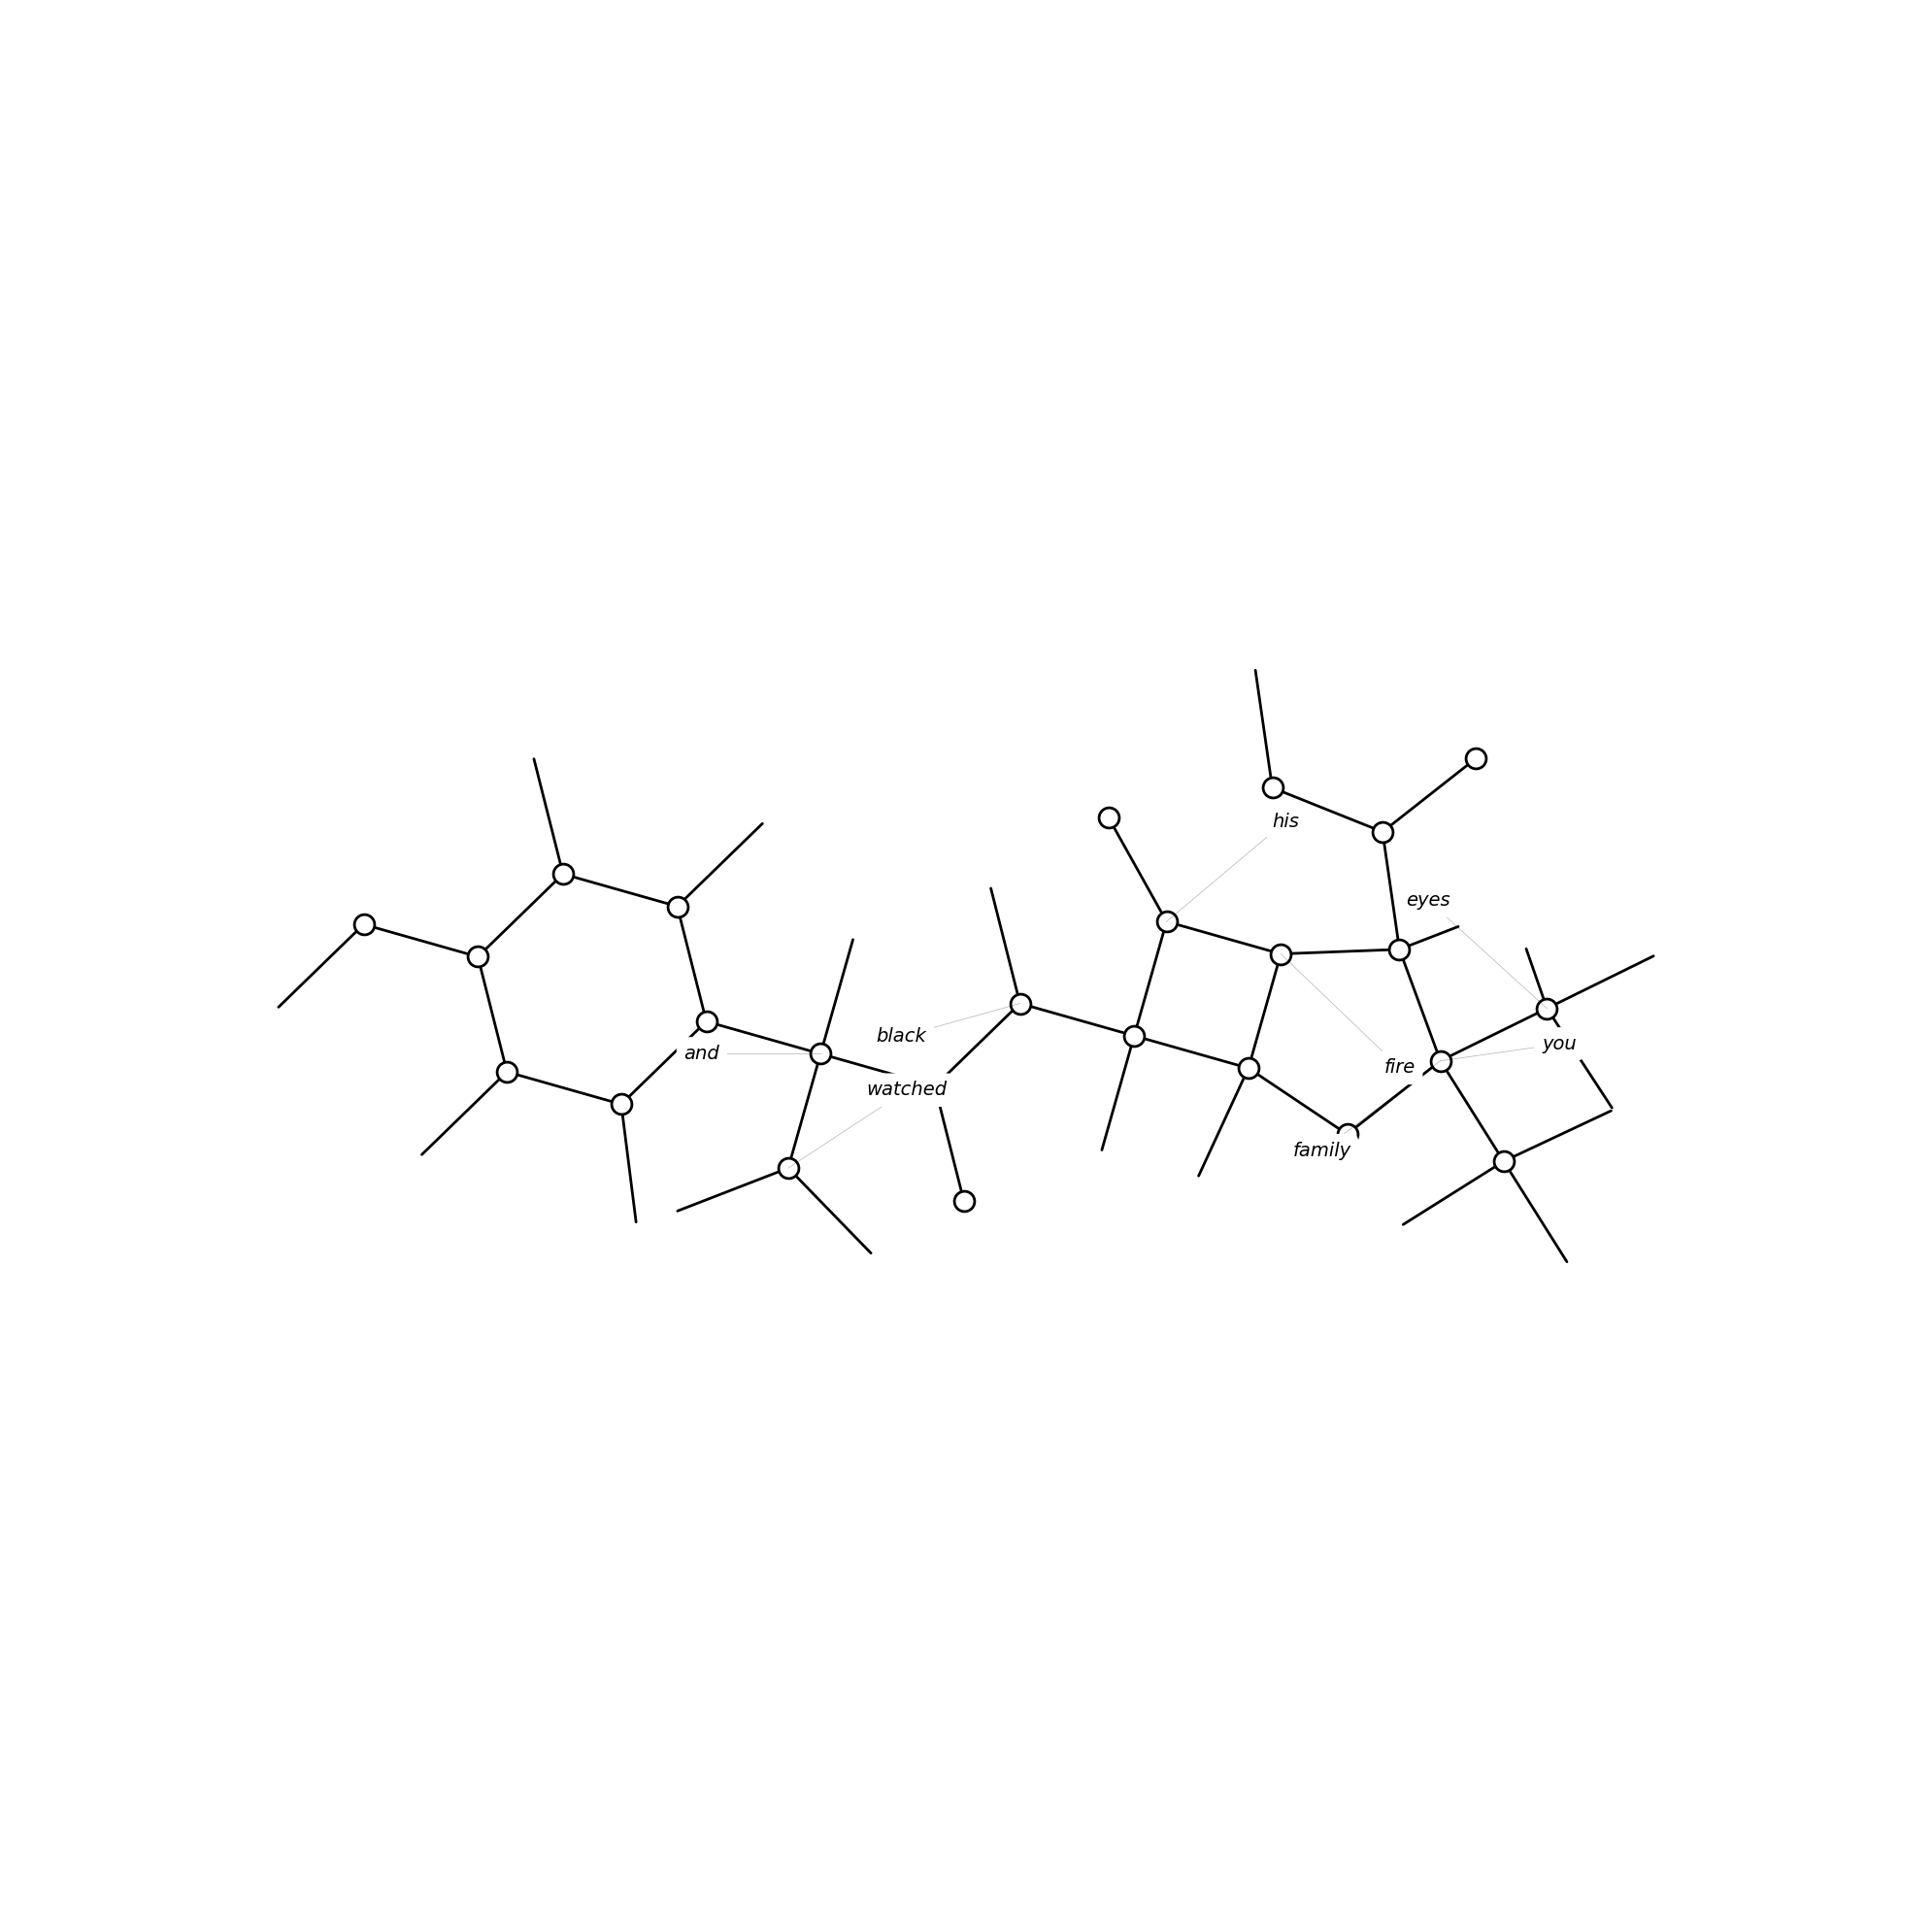

In [161]:
index = 0
print(df.iloc[index]['smiles'])
clean_bond_label_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# view = create_py3dmol_word_cloud(smiles, words, 
#                                   width=1000, 
#                                   height=1000,
#                                   surface_opacity=0.25,
#                                   label_fontsize=16)


In [170]:
def hybrid_word_bond_molecule(smiles, words_to_embed, 
                               font_size=10,
                               bond_linewidth=2,
                               show_hydrogens=False):
    """
    Hybrid approach: bonds WITH words are drawn as text,
    bonds WITHOUT words are drawn as clean lines
    
    Parameters:
    -----------
    smiles : str
        SMILES string
    words_to_embed : list of (word, bit_idx) tuples
        Words mapped to Morgan fingerprint bits
    """
    from rdkit import Chem
    from rdkit.Chem import AllChem
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Prepare molecule
    mol = Chem.MolFromSmiles(smiles)
    if not show_hydrogens:
        mol = Chem.RemoveHs(mol)
    else:
        mol = Chem.AddHs(mol)
    
    AllChem.Compute2DCoords(mol)
    
    fig, ax = plt.subplots(figsize=(20, 20), facecolor='white')
    conf = mol.GetConformer()
    
    # Get fingerprint info
    info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024, bitInfo=info)
    
    # Map bits to words and find which bonds they correspond to
    bit_to_word = {bit_idx: word for word, bit_idx in words_to_embed}
    
    bond_words = {}  # bond_idx -> word
    
    for bit_idx, word in bit_to_word.items():
        if bit_idx in info:
            atom_idx, rad = info[bit_idx][0]
            
            # Get the environment (bonds) for this bit
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
            
            # Assign word to a bond in this environment
            for bond_idx in env:
                if bond_idx not in bond_words:  # First available bond gets the word
                    bond_words[bond_idx] = word
                    break
    
    print(f"Mapped {len(bond_words)} words to bonds out of {mol.GetNumBonds()} total bonds")
    
    # Draw all bonds
    for bond in mol.GetBonds():
        bond_idx = bond.GetIdx()
        begin_idx = bond.GetBeginAtomIdx()
        end_idx = bond.GetEndAtomIdx()
        
        p1 = conf.GetAtomPosition(begin_idx)
        p2 = conf.GetAtomPosition(end_idx)
        
        if bond_idx in bond_words:
            # Draw as TEXT
            word = bond_words[bond_idx]
            
            # Calculate angle for text rotation
            angle = np.degrees(np.arctan2(p2.y - p1.y, p2.x - p1.x))
            
            # Keep text readable (not upside down)
            if angle > 90 or angle < -90:
                angle += 180
            
            # Midpoint
            mid_x, mid_y = (p1.x + p2.x) / 2, (p1.y + p2.y) / 2
            
            # Draw word as the bond
            ax.text(mid_x, mid_y, word,
                   rotation=angle,
                   rotation_mode='anchor',
                   ha='center', va='center',
                   fontsize=font_size, 
                   weight='bold',
                   color='black',
                   family='sans-serif')
        else:
            # Draw as STICK
            ax.plot([p1.x, p2.x], [p1.y, p2.y], 
                   'k-', linewidth=bond_linewidth, 
                   solid_capstyle='round',
                   zorder=1)
    
    # Draw atoms as circles
    for i in range(mol.GetNumAtoms()):
        atom = mol.GetAtomWithIdx(i)
        if not show_hydrogens and atom.GetSymbol() == 'H':
            continue
            
        pos = conf.GetAtomPosition(i)
        
        # Atom circle
        ax.plot(pos.x, pos.y, 'o', 
               markersize=0, 
               color='black', 
               markerfacecolor='white', 
               markeredgewidth=2,
               zorder=2)
    
    ax.axis('equal')
    ax.axis('off')
    ax.margins(0.15)
    plt.tight_layout()
    
    return fig, bond_words


CCCCCCCCCCC/C=C/C(C(COC1C(C(C(C(O1)CO)O)O)OC(=O)CCCCCCCCC/C=C/CCCCCCCC)NC(=O)C(CCCCCCCCCC/C=C\\C/C=C\\CCCCC)O)O
[   1   20   33   46   80  102  117  118  119  128  171  203  210  222
  227  233  243  259  278  292  294  299  332  362  371  375  401  416
  420  463  473  492  522  539  540  550  573  576  591  600  610  646
  650  656  682  687  693  694  695  731  739  740  775  794  807  820
  823  849  887  890  893  897  923  926  953  967 1019]
[('and', 1), ('she', 20), ('eyes', 33), ('be', 46), ('people', 80), ('music', 102), ('thing', 117), ('us', 118), ('some', 119), ('black', 128), ('soft', 171), ('own', 203), ('afraid', 210), ('walked', 222), ('moon', 227), ('blanket', 233), ('than', 243), ('enemy', 259), ('set', 278), ('each', 292), ('nearly', 294), ('legs', 299), ('money', 332), ('many', 362), ('sell', 371), ('doorway', 375), ('close', 401), ('animals', 416), ('canoes', 420), ('estuary', 463), ('picked', 473), ('everything', 492), ('knuckles', 522), ('settled', 539), ('clean

(<Figure size 2000x2000 with 1 Axes>,
 {49: 'she',
  52: 'be',
  26: 'music',
  48: 'thing',
  14: 'us',
  2: 'some',
  63: 'soft',
  17: 'own',
  20: 'afraid',
  23: 'walked',
  72: 'moon',
  24: 'blanket',
  30: 'than',
  53: 'enemy',
  12: 'set',
  15: 'each',
  0: 'nearly',
  16: 'legs',
  10: 'money',
  27: 'many',
  51: 'sell',
  13: 'doorway',
  9: 'close',
  8: 'animals',
  1: 'canoes',
  19: 'estuary',
  18: 'picked',
  22: 'everything',
  73: 'knuckles',
  50: 'settled',
  29: 'clean',
  11: 'half',
  25: 'thumb',
  21: 'thou',
  64: 'late',
  28: 'wondered',
  74: 'ring',
  38: 'soul',
  65: 'laughed'})

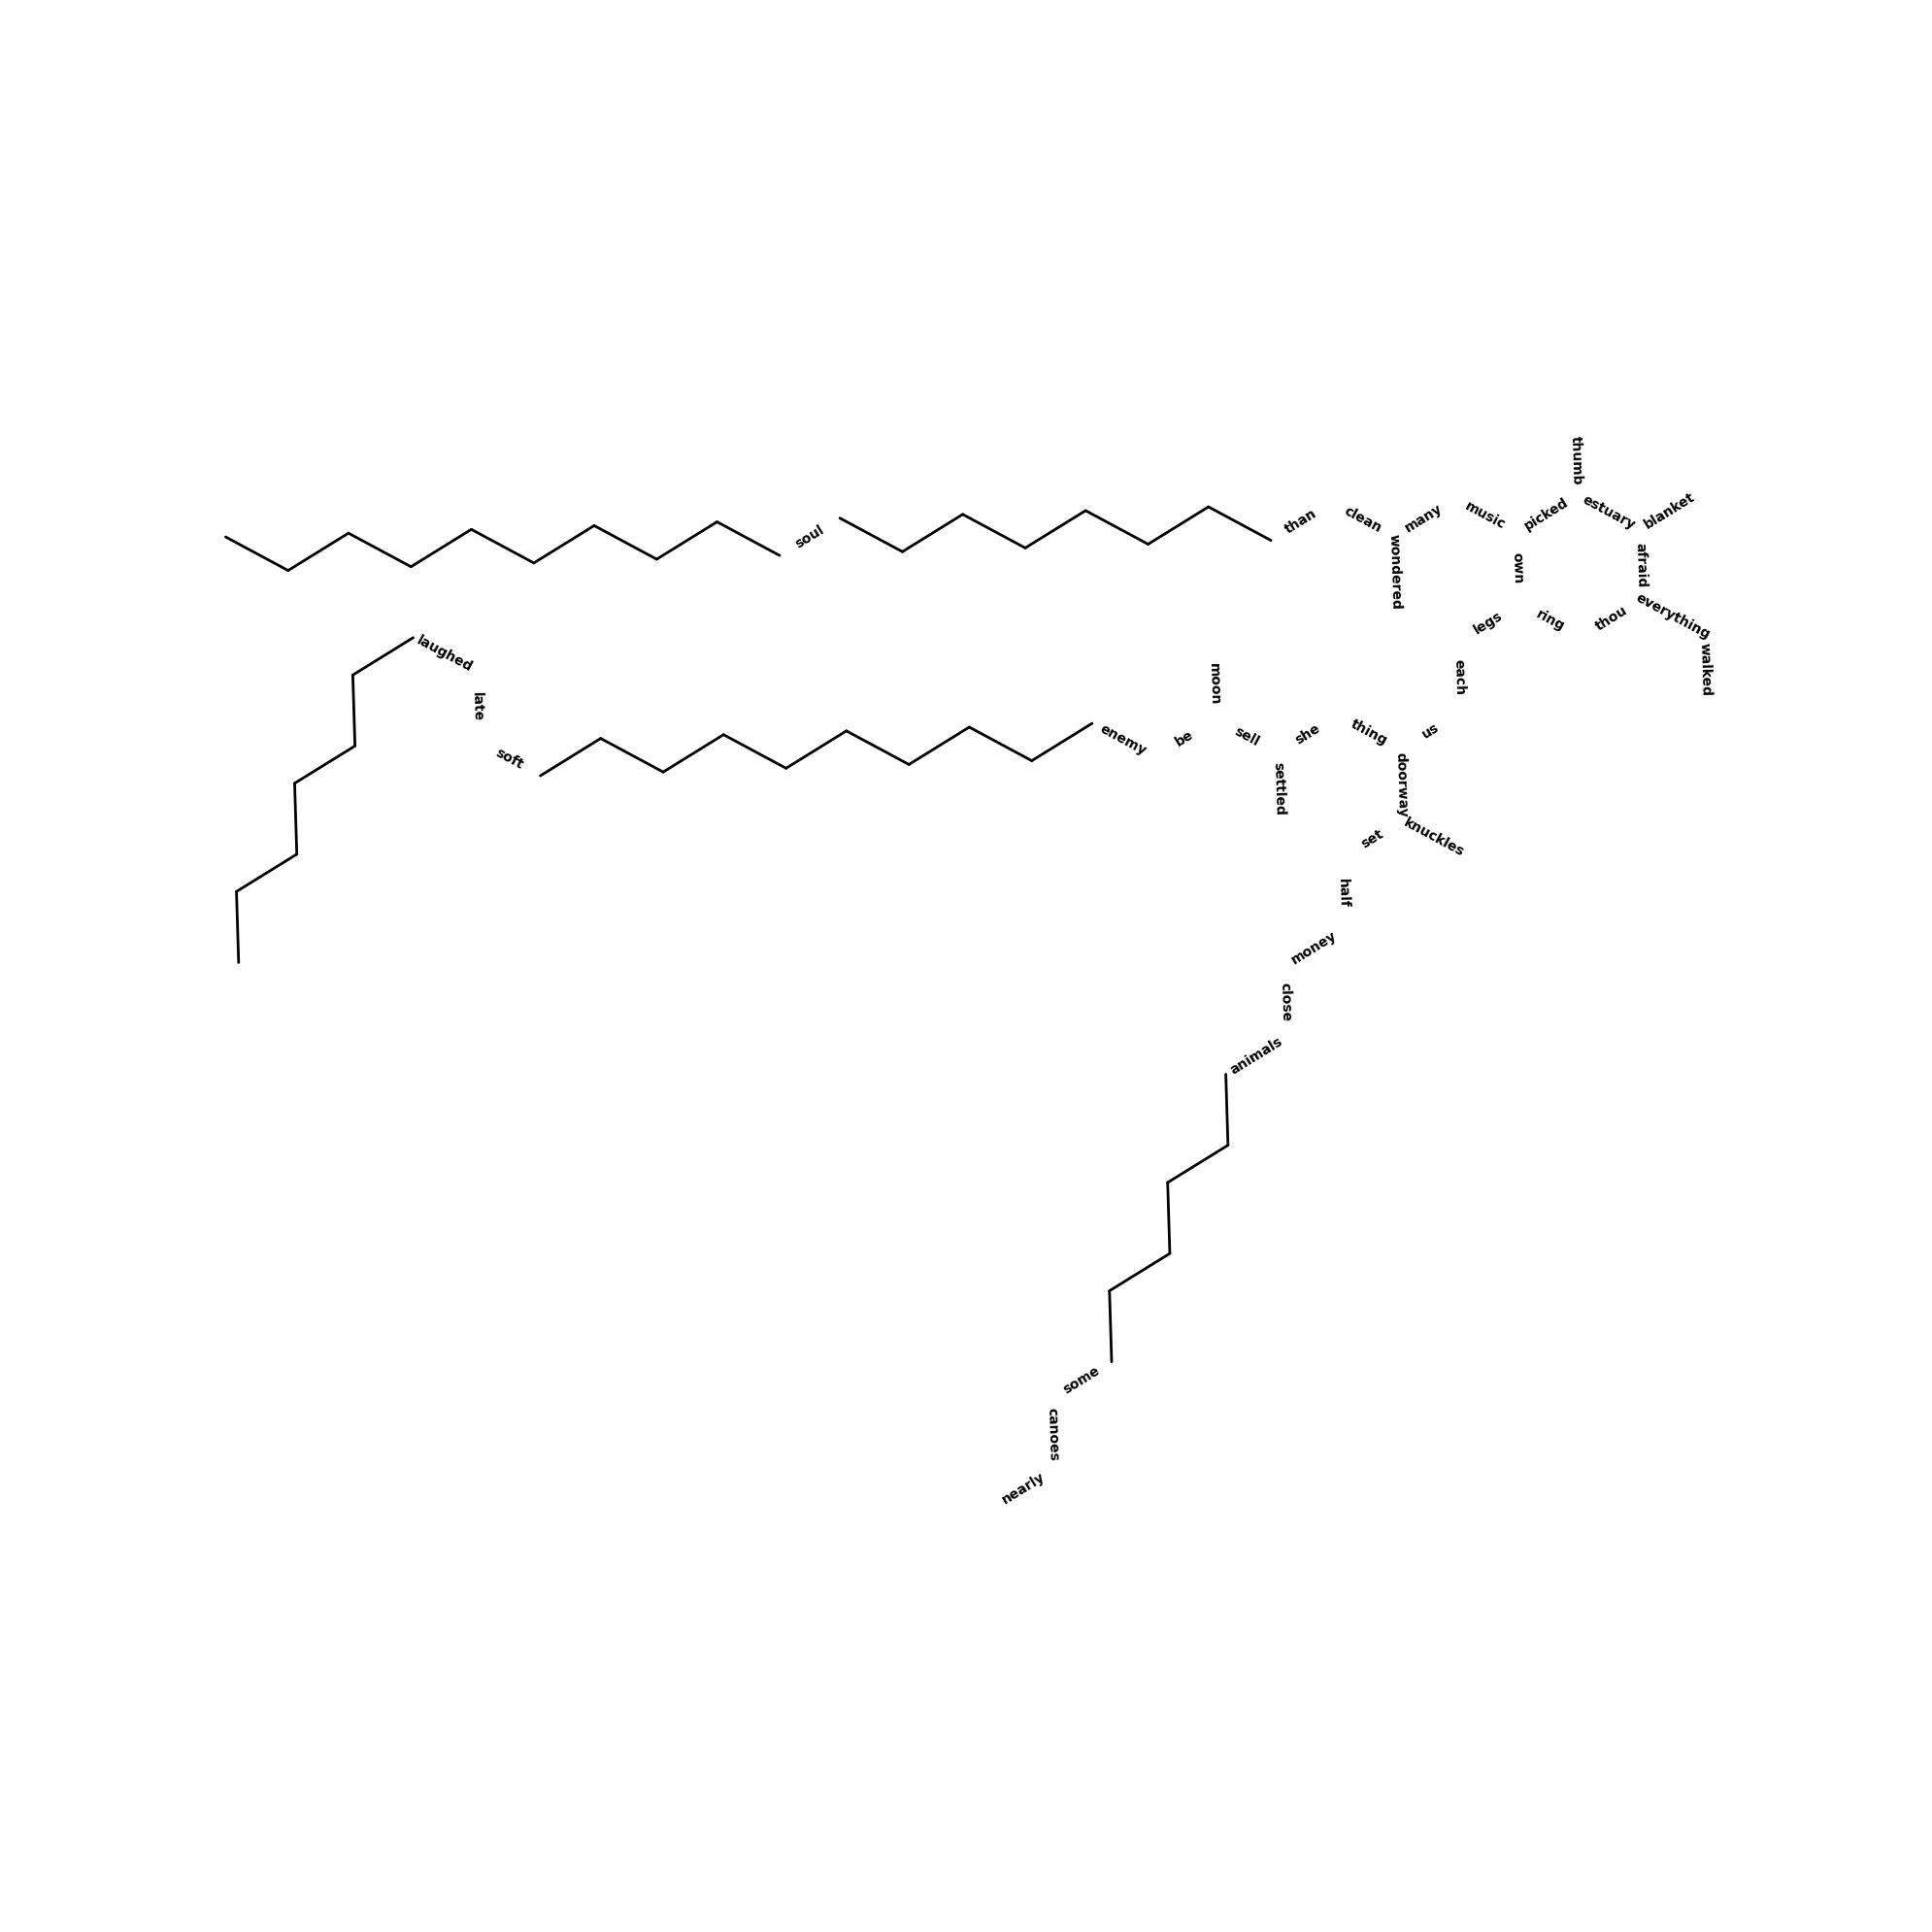

In [ ]:
index = 1
print(df.iloc[index]['smiles'])
hybrid_word_bond_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# view = create_py3dmol_word_cloud(smiles, words, 
#                                   width=1000, 
#                                   height=1000,
#                                   surface_opacity=0.25,
#                                   label_fontsize=16)


In [ ]:
FAMILY=  'Courier New'

def typewriter_molecule_art_v2(smiles, words_to_embed, 
                               target_length=10,
                               spacing_char='-',
                               font_size=11,
                               bond_linewidth=2.5,
                               vertical_jitter=0.02,
                               letter_spacing_jitter=0.01,
                               show_hydrogens=False,
                               radius=2):
    """
    Cleaner typewriter-style molecule with better spacing
    Back to basics: only radius 2, tighter letter spacing
    """
    from rdkit import Chem
    from rdkit.Chem import AllChem
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Prepare molecule
    mol = Chem.MolFromSmiles(smiles)
    if not show_hydrogens:
        mol = Chem.RemoveHs(mol)
    else:
        mol = Chem.AddHs(mol)
    
    AllChem.Compute2DCoords(mol)
    
    fig, ax = plt.subplots(figsize=(20, 20), facecolor='white')
    conf = mol.GetConformer()
    
    # Get fingerprint info - ONLY radius 2
    info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=1024, bitInfo=info)
    
    # Map bits to words
    bit_to_word = {bit_idx: word for word, bit_idx in words_to_embed}
    
    # Assign words to bonds
    bond_words = {}
    
    for bit_idx, word in bit_to_word.items():
        if bit_idx in info:
            atom_idx, rad = info[bit_idx][0]
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
            
            for bond_idx in env:
                if bond_idx not in bond_words:
                    bond_words[bond_idx] = word
                    break
    
    print(f"Mapped {len(bond_words)} words to {mol.GetNumBonds()} bonds")
    print(f"Bonds with words: {sorted(bond_words.keys())}")
    print(f"Bonds without words: {[b.GetIdx() for b in mol.GetBonds() if b.GetIdx() not in bond_words]}")
    
    def format_word_for_bond(word, target_len, spacing_char):
        """Format word to target length with tighter spacing"""
        if spacing_char == '-' or spacing_char == '.':
            # Insert spacing char between letters: "hello" -> "h-e-l-l-o"
            spaced = spacing_char.join(list(word))
            if len(spaced) < target_len:
                # Pad equally on both sides
                padding_needed = target_len - len(spaced)
                left_pad = padding_needed // 2
                right_pad = padding_needed - left_pad
                spaced = spacing_char * left_pad + spaced + spacing_char * right_pad
            return spaced[:target_len]
        elif spacing_char is None:
            # Repeat word: "hello" -> "hellohellohel"
            repeated = (word * (target_len // len(word) + 1))[:target_len]
            return repeated
        else:  # spacing_char == ' ' or other
            # Space out letters
            spaced = spacing_char.join(list(word))
            if len(spaced) < target_len:
                padding_needed = target_len - len(spaced)
                left_pad = padding_needed // 2
                right_pad = padding_needed - left_pad
                spaced = spacing_char * left_pad + spaced + spacing_char * right_pad
            return spaced[:target_len]
    
    def draw_jittered_text(ax, text, x, y, angle, fontsize, jitter_y, jitter_x):
        """Draw text with subtle jitter - TIGHTER SPACING"""
        angle_rad = np.radians(angle)
        dx = np.cos(angle_rad)
        dy = np.sin(angle_rad)
        
        perp_dx = -np.sin(angle_rad)
        perp_dy = np.cos(angle_rad)
        
        # TIGHTER character spacing
        # TODO: yitong make this tighter!
        char_width = fontsize * 0.0085  # Reduced from 0.06
        
        text_len = len(text)
        start_offset = -(text_len * char_width) / 2
        
        for i, char in enumerate(text):
            # Horizontal position along the bond
            h_offset = start_offset + i * char_width
            h_offset += np.random.uniform(-jitter_x, jitter_x)
            
            # Vertical jitter (perpendicular to bond)
            v_offset = np.random.uniform(-jitter_y, jitter_y)
            
            char_x = x + h_offset * dx + v_offset * perp_dx
            char_y = y + h_offset * dy + v_offset * perp_dy
            
            # Very slight rotation jitter
            char_angle = angle + np.random.uniform(-1, 1)
            
            ax.text(char_x, char_y, char,
                   rotation=char_angle,
                   rotation_mode='anchor',
                   ha='center', va='center',
                   fontsize=fontsize,
                   weight='normal',
                   family=FAMILY,
                   color='black')
    
    # Draw all bonds
    for bond in mol.GetBonds():
        bond_idx = bond.GetIdx()
        begin_idx = bond.GetBeginAtomIdx()
        end_idx = bond.GetEndAtomIdx()
        
        p1 = conf.GetAtomPosition(begin_idx)
        p2 = conf.GetAtomPosition(end_idx)
        
        if bond_idx in bond_words:
            # Draw as TYPEWRITER TEXT
            word = bond_words[bond_idx]
            formatted_word = format_word_for_bond(word, target_length, spacing_char)
            
            # Calculate angle
            angle = np.degrees(np.arctan2(p2.y - p1.y, p2.x - p1.x))
            
            # Keep text readable (not upside down)
            if angle > 90 or angle < -90:
                angle += 180
            
            # Midpoint
            mid_x, mid_y = (p1.x + p2.x) / 2, (p1.y + p2.y) / 2
            
            # Draw with jitter
            draw_jittered_text(ax, formatted_word, mid_x, mid_y, angle, 
                             font_size, vertical_jitter, letter_spacing_jitter)
        # else:
        #     # Draw as STICK (bonds without words)
        #     ax.plot([p1.x, p2.x], [p1.y, p2.y], 
        #            'k-', linewidth=bond_linewidth, 
        #            solid_capstyle='round',
        #            zorder=1,
        #            alpha=0.8)
        else:
            # Draw as DASHED LINE (typewriter style: ------)
            bond_length = np.sqrt((p2.x - p1.x)**2 + (p2.y - p1.y)**2)
            num_dashes = int(bond_length * 8)  # Adjust density
            
            dash_text = '-' * num_dashes
            angle = np.degrees(np.arctan2(p2.y - p1.y, p2.x - p1.x))
            
            # Keep dashes readable
            if angle > 90 or angle < -90:
                angle += 180
            
            mid_x, mid_y = (p1.x + p2.x) / 2, (p1.y + p2.y) / 2
            
            # Draw dashes without jitter for cleaner lines
            ax.text(mid_x, mid_y, dash_text,
                   rotation=angle,
                   rotation_mode='anchor',
                   ha='center', va='center',
                   fontsize=font_size * 0.8,  # Slightly smaller than words
                   weight='normal',
                   family=FAMILY,
                   color='black',
                   alpha=0.7,
                   zorder=1)
    
    # Draw atoms
    for i in range(mol.GetNumAtoms()):
        atom = mol.GetAtomWithIdx(i)
        if not show_hydrogens and atom.GetSymbol() == 'H':
            continue
            
        pos = conf.GetAtomPosition(i)
        
        ax.plot(pos.x, pos.y, 'o', 
               markersize=0, 
               color='black', 
               markerfacecolor='white', 
               markeredgewidth=2.5,
               zorder=2)
    
    ax.axis('equal')
    ax.axis('off')
    ax.margins(0.12)
    plt.tight_layout()
    
    return fig, bond_words





[   1    5   18   33   36  125  126  128  130  147  181  233  250  251
  255  274  289  314  341  356  362  387  389  407  573  578  585  607
  611  650  673  675  697  709  726  745  753  754  786  807  829  849
  893  913  919  935 1019]
[('and', 1), ('his', 5), ('had', 18), ('eyes', 33), ('you', 36), ('family', 125), ('fire', 126), ('black', 128), ('door', 130), ('watched', 147), ('air', 181), ('blanket', 233), ('dealer', 250), ('still', 251), ('slipped', 255), ('secret', 274), ('almost', 289), ('cave', 314), ('price', 341), ('followed', 356), ('many', 362), ('nose', 387), ('waves', 389), ('warm', 407), ('together', 573), ('yes', 578), ('disappeared', 585), ('school', 607), ('desert', 611), ('arranged', 650), ('death', 673), ('boy', 675), ('silver', 697), ('paper', 709), ('continued', 726), ('below', 745), ('faces', 753), ('whisper', 754), ('fool', 786), ('pools', 807), ('pile', 829), ('laughed', 849), ('although', 893), ('thrown', 913), ('next', 919), ('really', 935), ('burning', 1

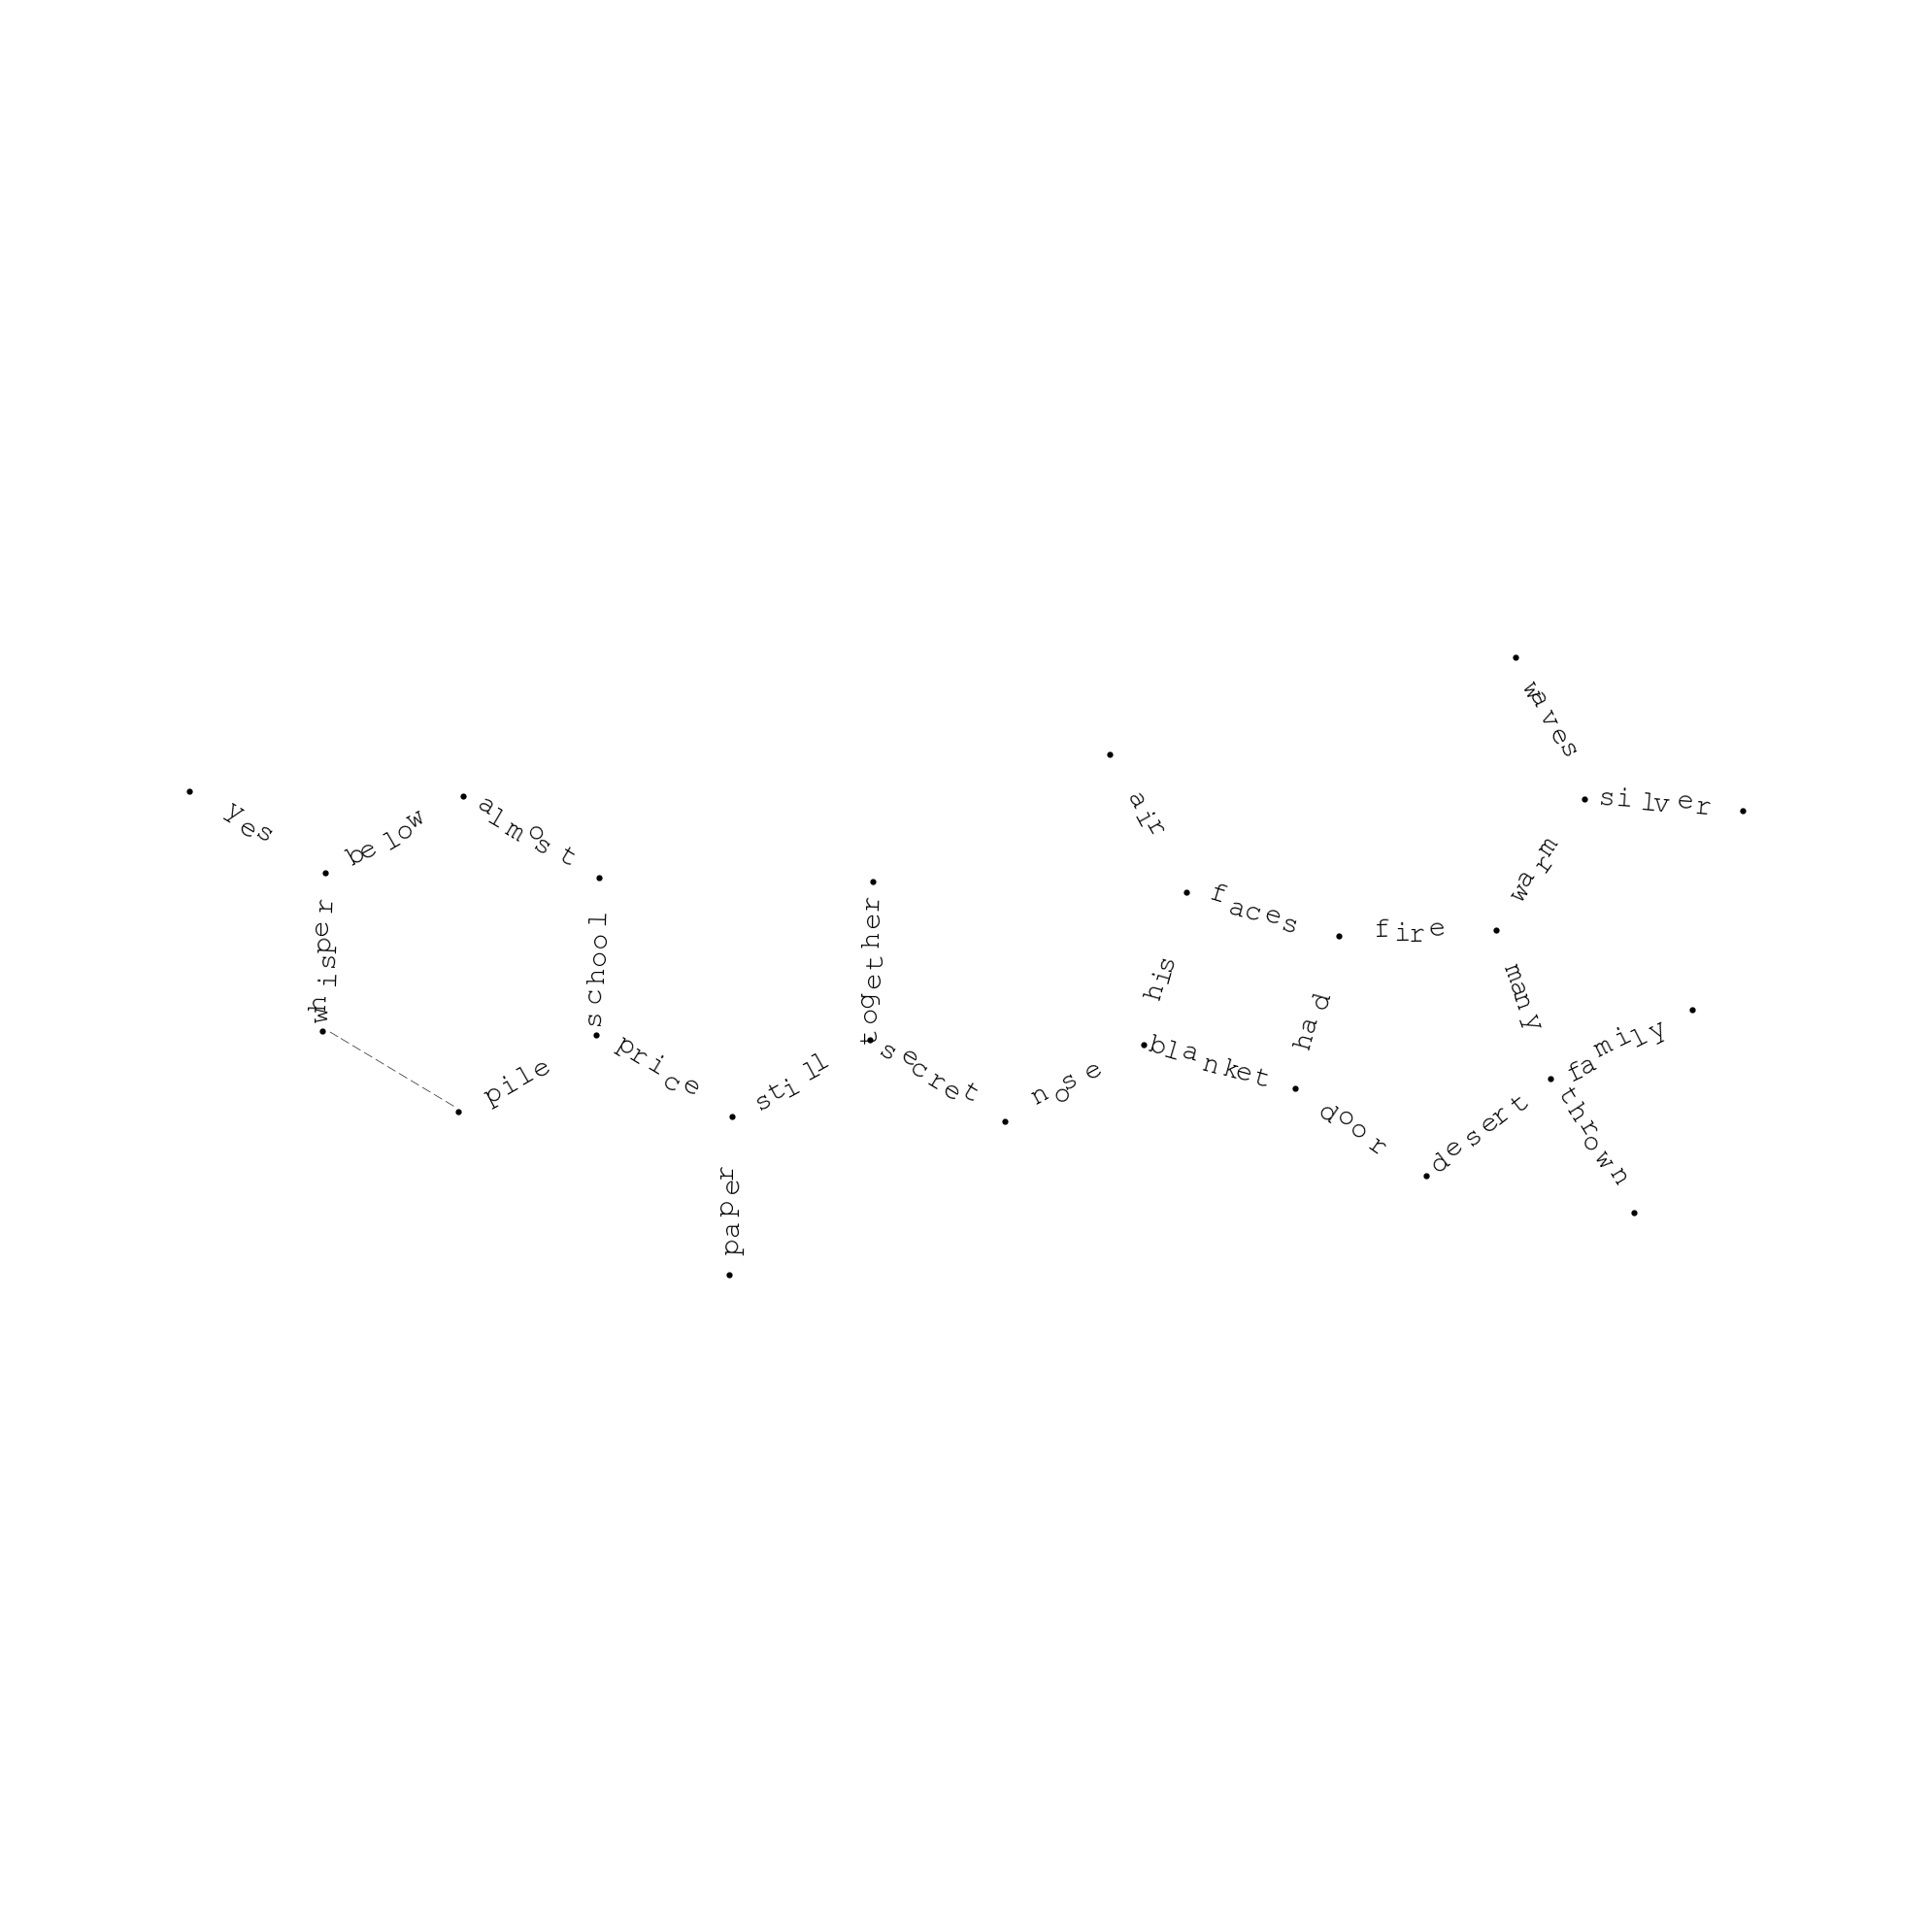

In [224]:
index = 0
# print(df.iloc[index]['smiles'])
# hybrid_word_bond_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# 1. With dashes (classic typewriter)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    words_to_embed=row_to_words(fps_array[index]),
    target_length=12,
    spacing_char='',
    font_size=21,
    vertical_jitter=0.05,
    letter_spacing_jitter=0.04
)
# plt.savefig('typewriter_dashes.png', dpi=300, bbox_inches='tight', facecolor='white')



[   1   20   33   46   80  102  117  118  119  128  171  203  210  222
  227  233  243  259  278  292  294  299  332  362  371  375  401  416
  420  463  473  492  522  539  540  550  573  576  591  600  610  646
  650  656  682  687  693  694  695  731  739  740  775  794  807  820
  823  849  887  890  893  897  923  926  953  967 1019]
[('and', 1), ('she', 20), ('eyes', 33), ('be', 46), ('people', 80), ('music', 102), ('thing', 117), ('us', 118), ('some', 119), ('black', 128), ('soft', 171), ('own', 203), ('afraid', 210), ('walked', 222), ('moon', 227), ('blanket', 233), ('than', 243), ('enemy', 259), ('set', 278), ('each', 292), ('nearly', 294), ('legs', 299), ('money', 332), ('many', 362), ('sell', 371), ('doorway', 375), ('close', 401), ('animals', 416), ('canoes', 420), ('estuary', 463), ('picked', 473), ('everything', 492), ('knuckles', 522), ('settled', 539), ('clean', 540), ('half', 550), ('together', 573), ('thumb', 576), ('destroyed', 591), ('washed', 600), ('thou', 610), (

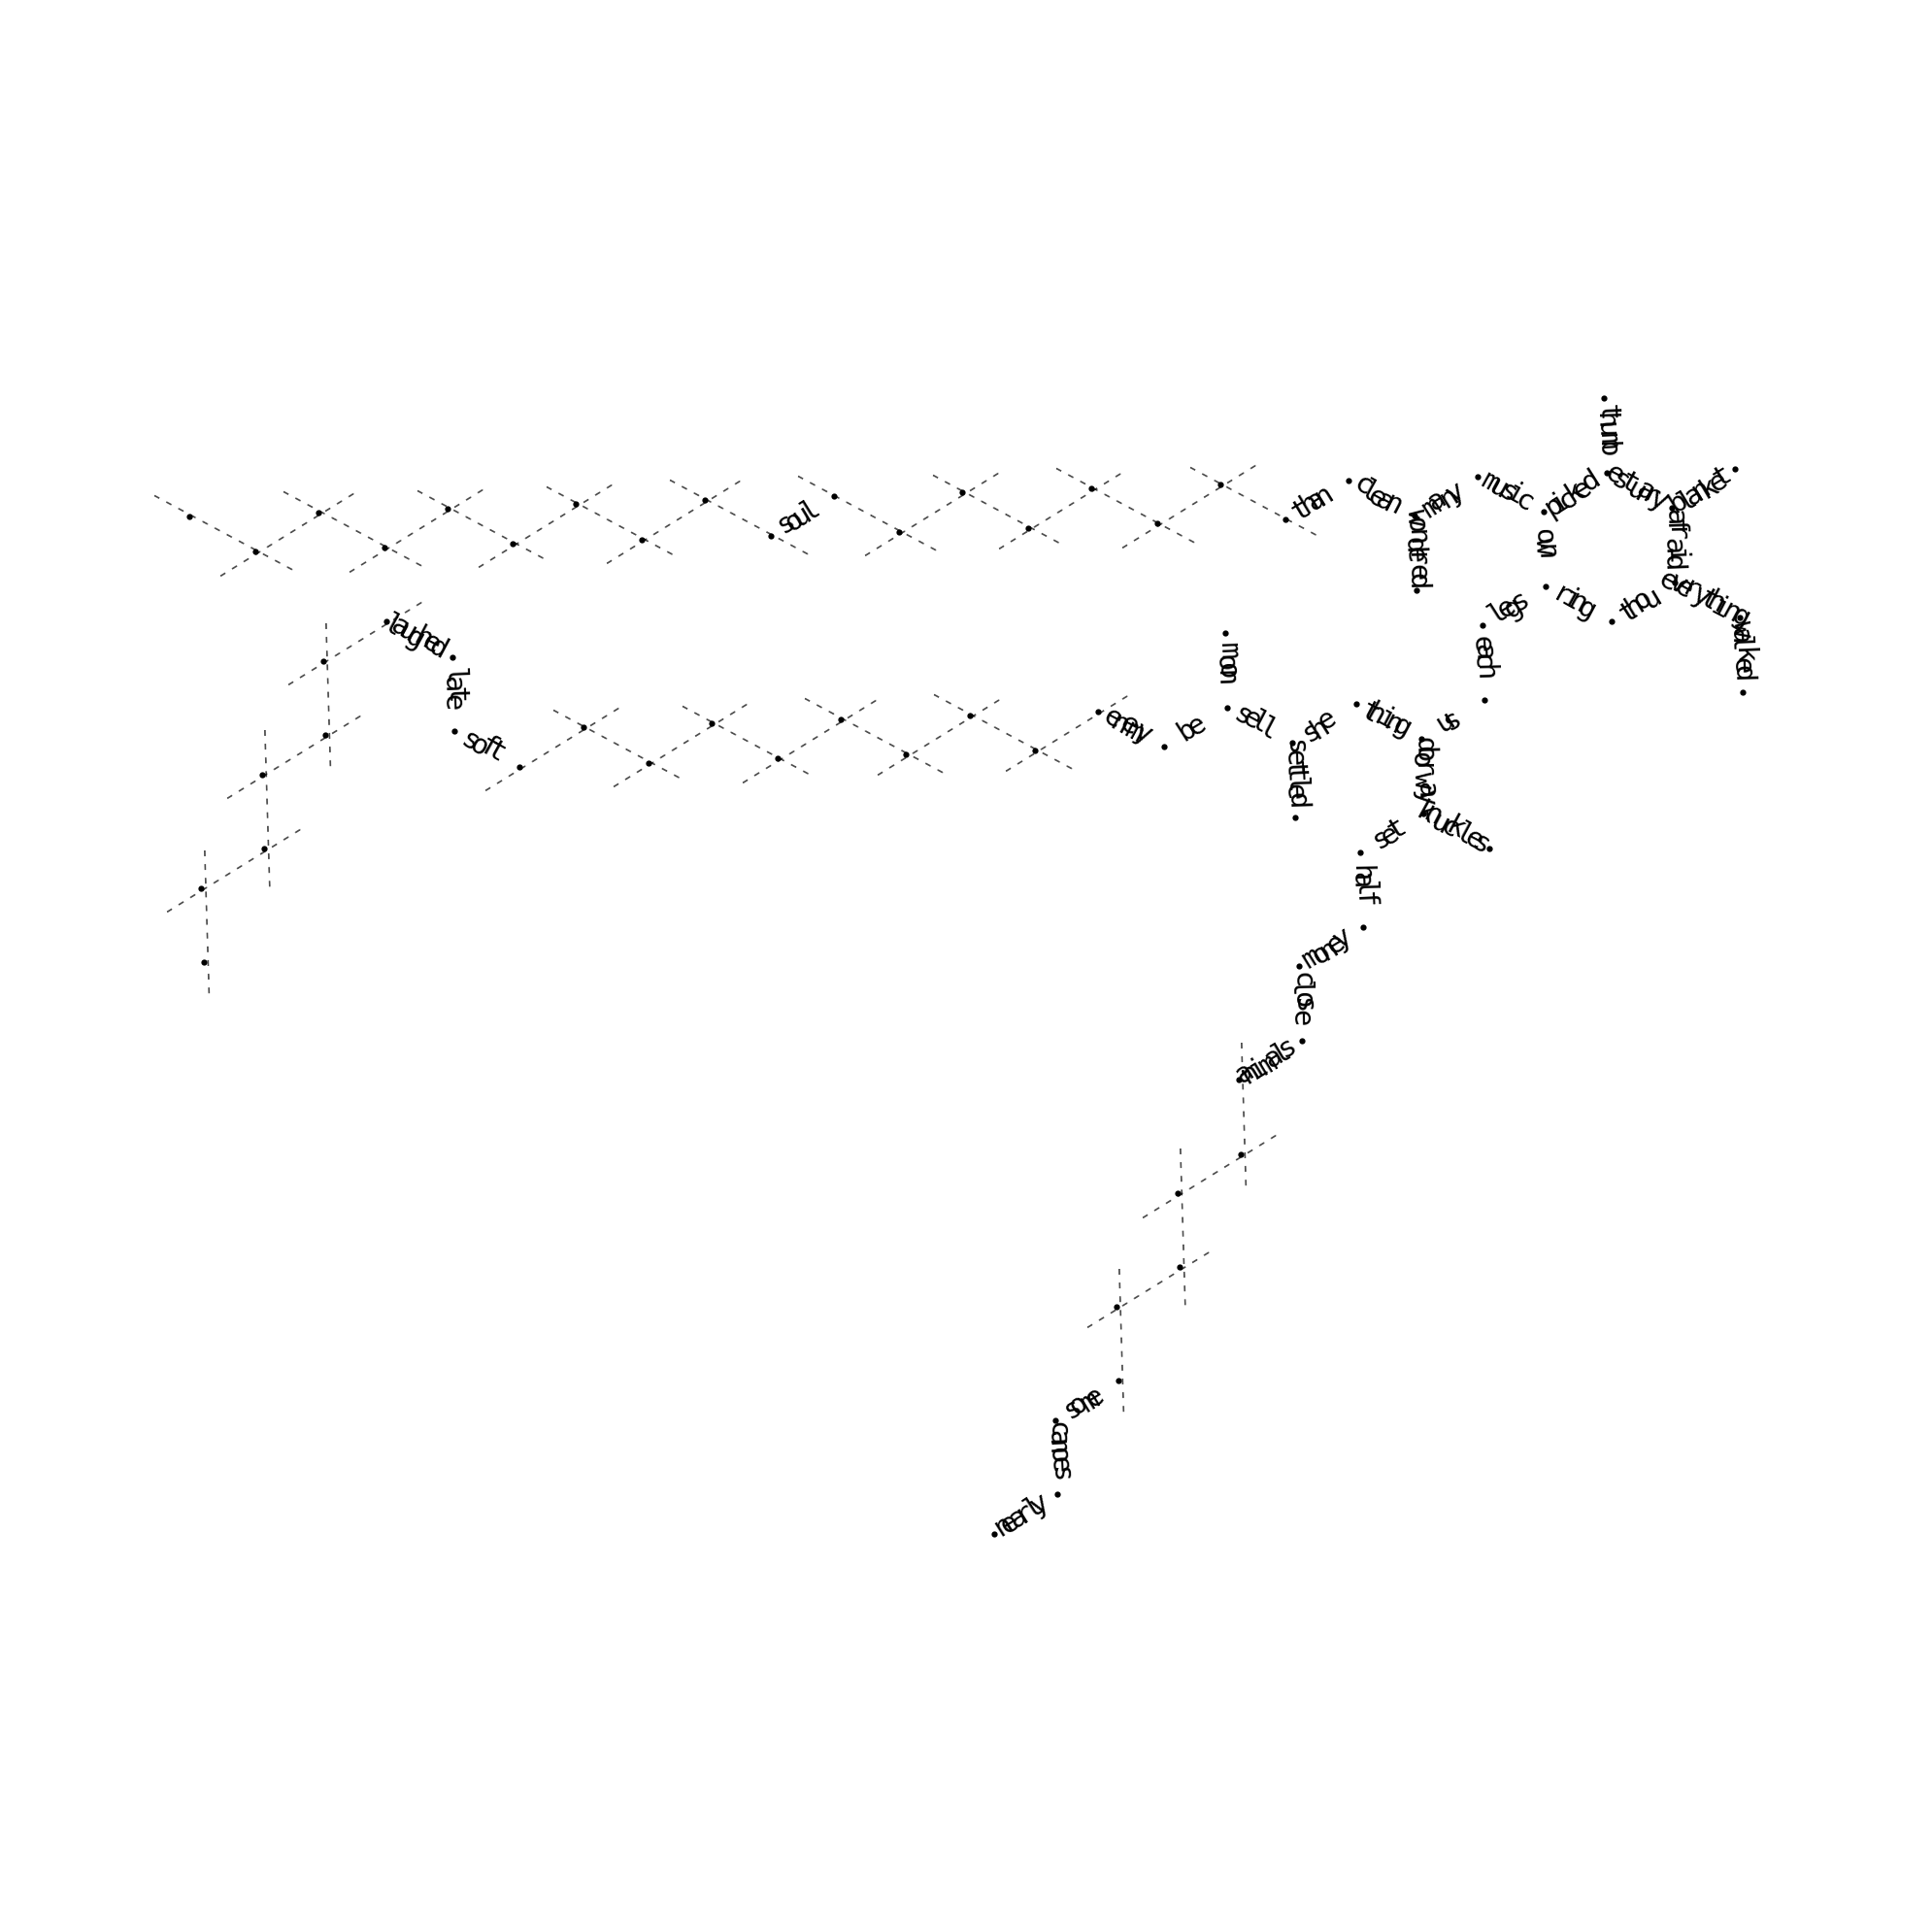

In [220]:
index = 1
# print(df.iloc[index]['smiles'])
# hybrid_word_bond_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# 1. With dashes (classic typewriter)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    words_to_embed=row_to_words(fps_array[index]),
    target_length=12,
    spacing_char='',
    font_size=21,
    vertical_jitter=0.05,
    letter_spacing_jitter=0.04
)
# plt.savefig('typewriter_dashes.png', dpi=300, bbox_inches='tight', facecolor='white')



[   1   20   33   46   80  102  117  118  119  128  171  203  210  222
  227  233  243  259  278  292  294  299  332  362  371  375  401  416
  420  463  473  492  522  539  540  550  573  576  591  600  610  646
  650  656  682  687  693  694  695  731  739  740  775  794  807  820
  823  849  887  890  893  897  923  926  953  967 1019]
[('and', 1), ('she', 20), ('eyes', 33), ('be', 46), ('people', 80), ('music', 102), ('thing', 117), ('us', 118), ('some', 119), ('black', 128), ('soft', 171), ('own', 203), ('afraid', 210), ('walked', 222), ('moon', 227), ('blanket', 233), ('than', 243), ('enemy', 259), ('set', 278), ('each', 292), ('nearly', 294), ('legs', 299), ('money', 332), ('many', 362), ('sell', 371), ('doorway', 375), ('close', 401), ('animals', 416), ('canoes', 420), ('estuary', 463), ('picked', 473), ('everything', 492), ('knuckles', 522), ('settled', 539), ('clean', 540), ('half', 550), ('together', 573), ('thumb', 576), ('destroyed', 591), ('washed', 600), ('thou', 610), (

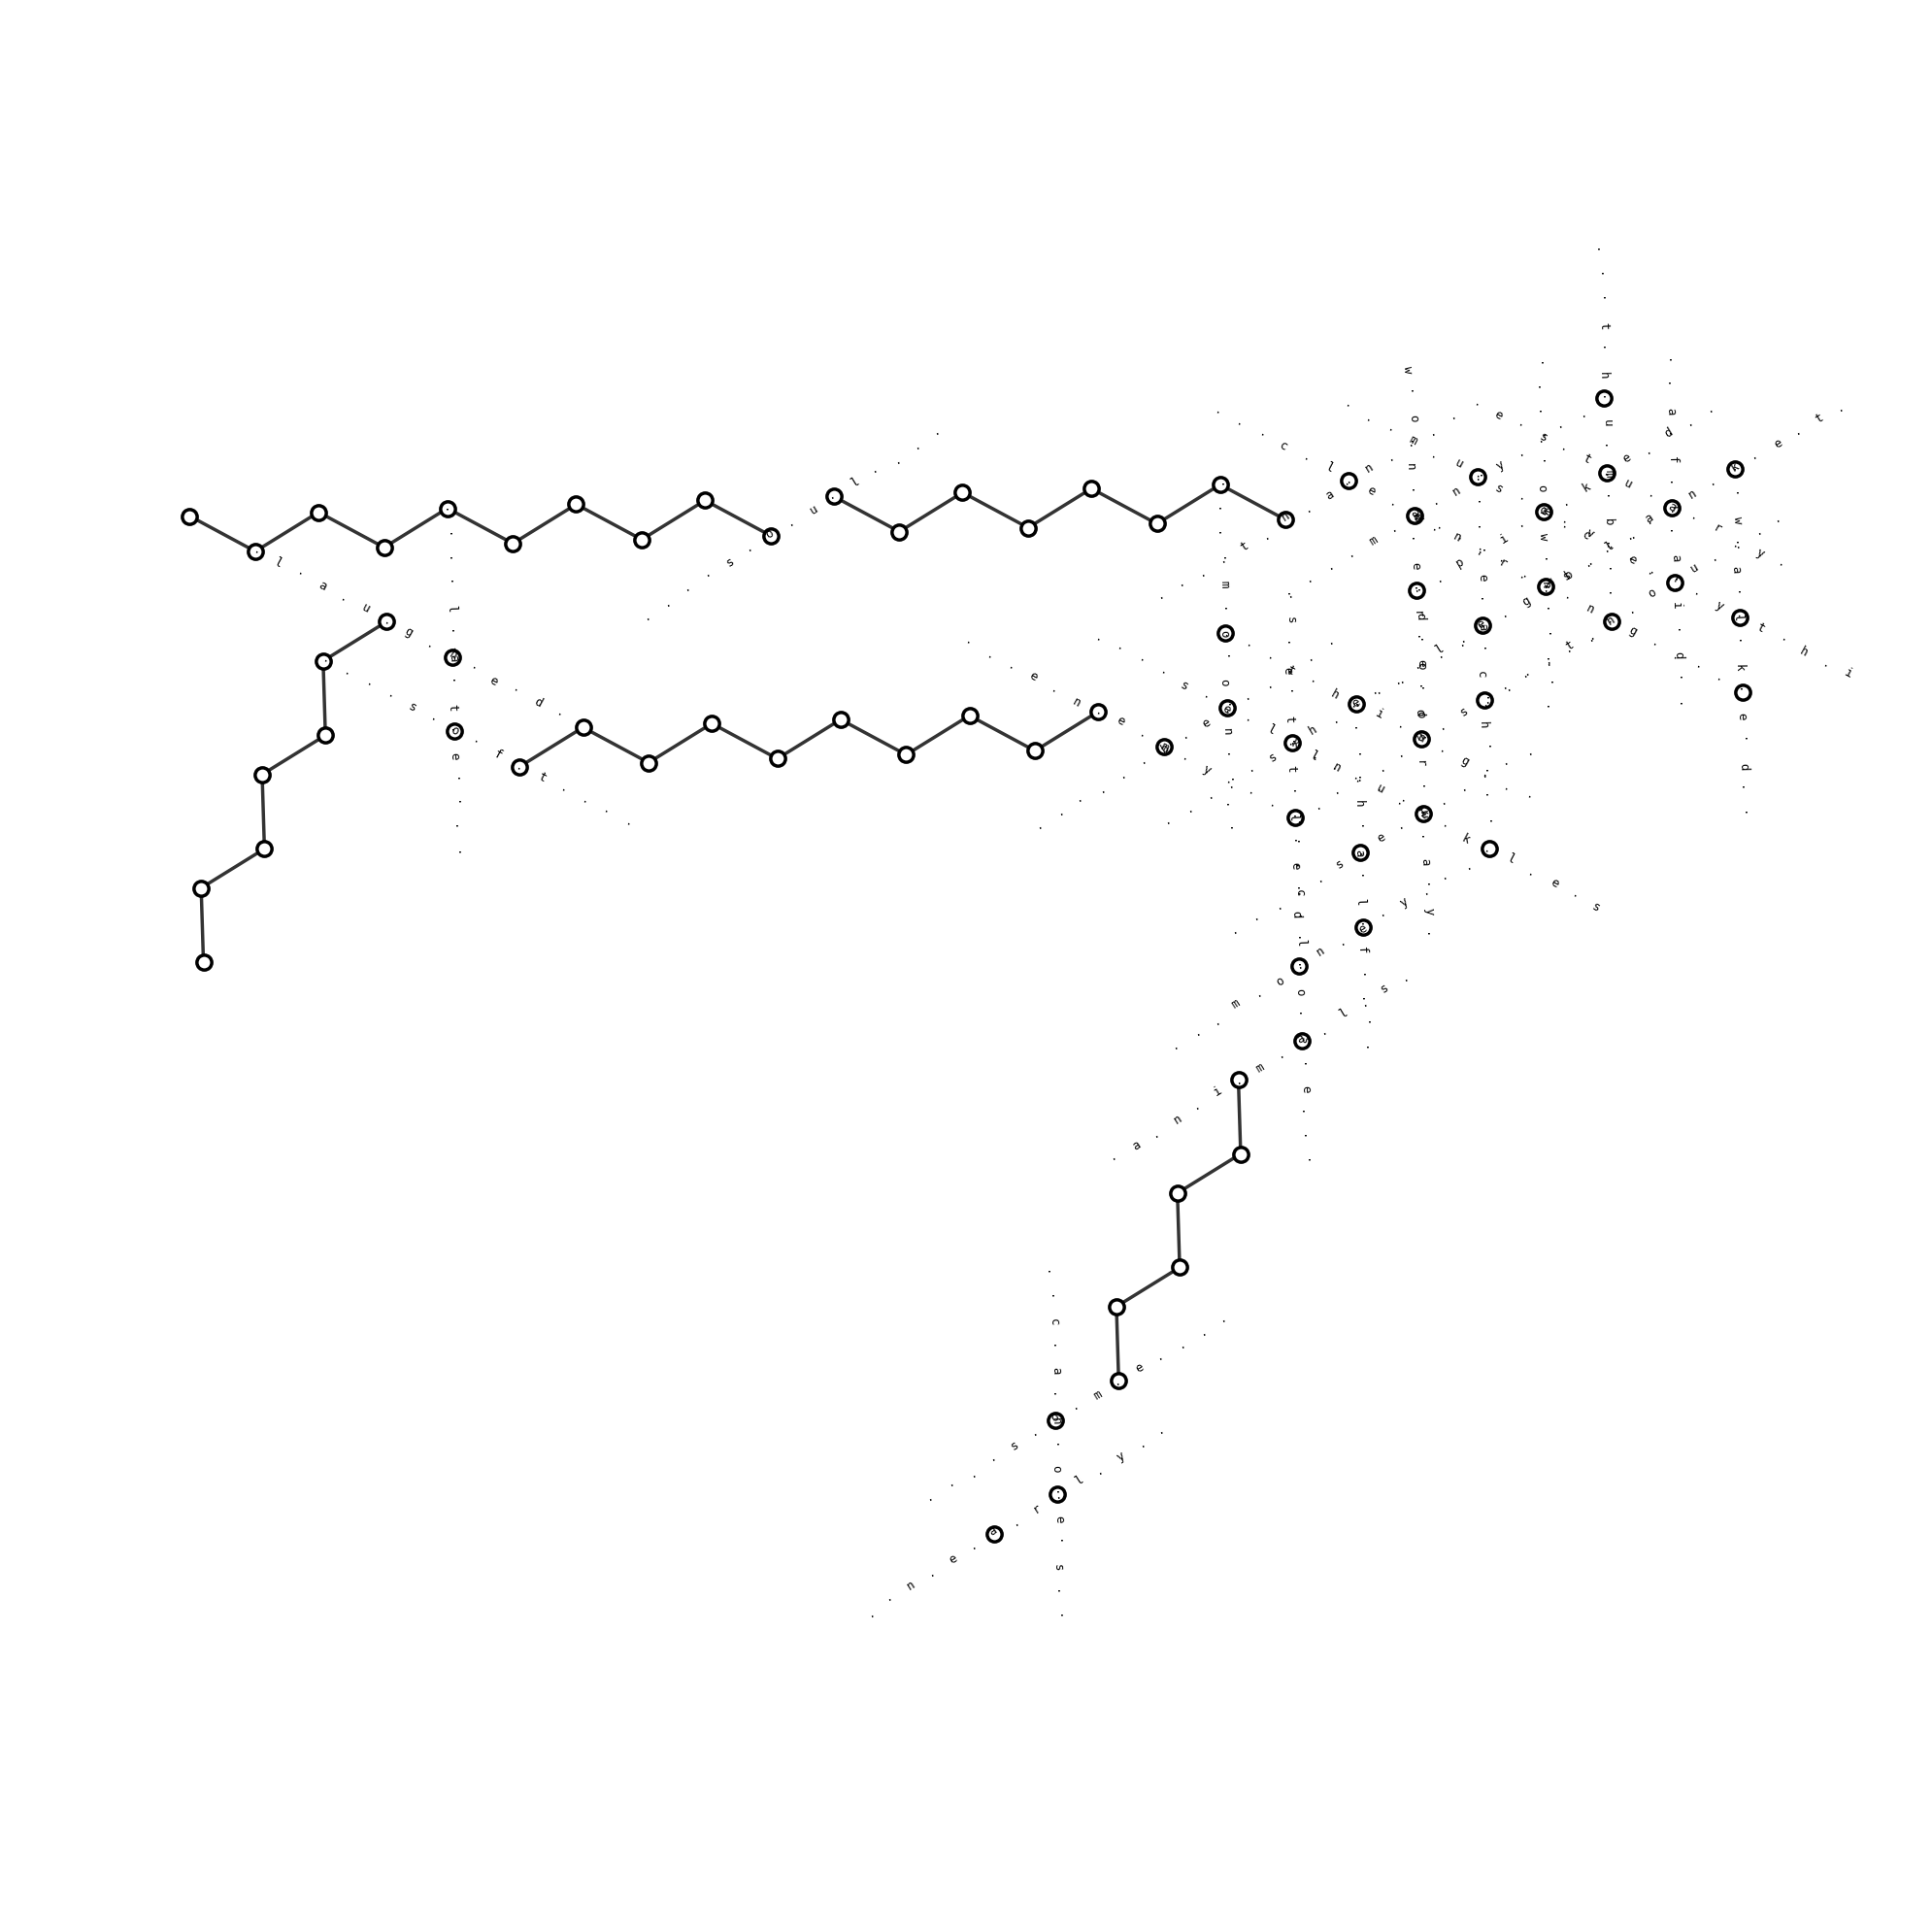

In [182]:
index = 1

# 2. With dots (more delicate)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    words_to_embed=row_to_words(fps_array[index]),
    target_length=15,
    spacing_char='.',
    font_size=9,
    vertical_jitter=0.06,
    letter_spacing_jitter=0.02
)
# plt.savefig('typewriter_dots.png', dpi=300, bbox_inches='tight', facecolor='white')


[   1   20   33   46   80  102  117  118  119  128  171  203  210  222
  227  233  243  259  278  292  294  299  332  362  371  375  401  416
  420  463  473  492  522  539  540  550  573  576  591  600  610  646
  650  656  682  687  693  694  695  731  739  740  775  794  807  820
  823  849  887  890  893  897  923  926  953  967 1019]
[('and', 1), ('she', 20), ('eyes', 33), ('be', 46), ('people', 80), ('music', 102), ('thing', 117), ('us', 118), ('some', 119), ('black', 128), ('soft', 171), ('own', 203), ('afraid', 210), ('walked', 222), ('moon', 227), ('blanket', 233), ('than', 243), ('enemy', 259), ('set', 278), ('each', 292), ('nearly', 294), ('legs', 299), ('money', 332), ('many', 362), ('sell', 371), ('doorway', 375), ('close', 401), ('animals', 416), ('canoes', 420), ('estuary', 463), ('picked', 473), ('everything', 492), ('knuckles', 522), ('settled', 539), ('clean', 540), ('half', 550), ('together', 573), ('thumb', 576), ('destroyed', 591), ('washed', 600), ('thou', 610), (

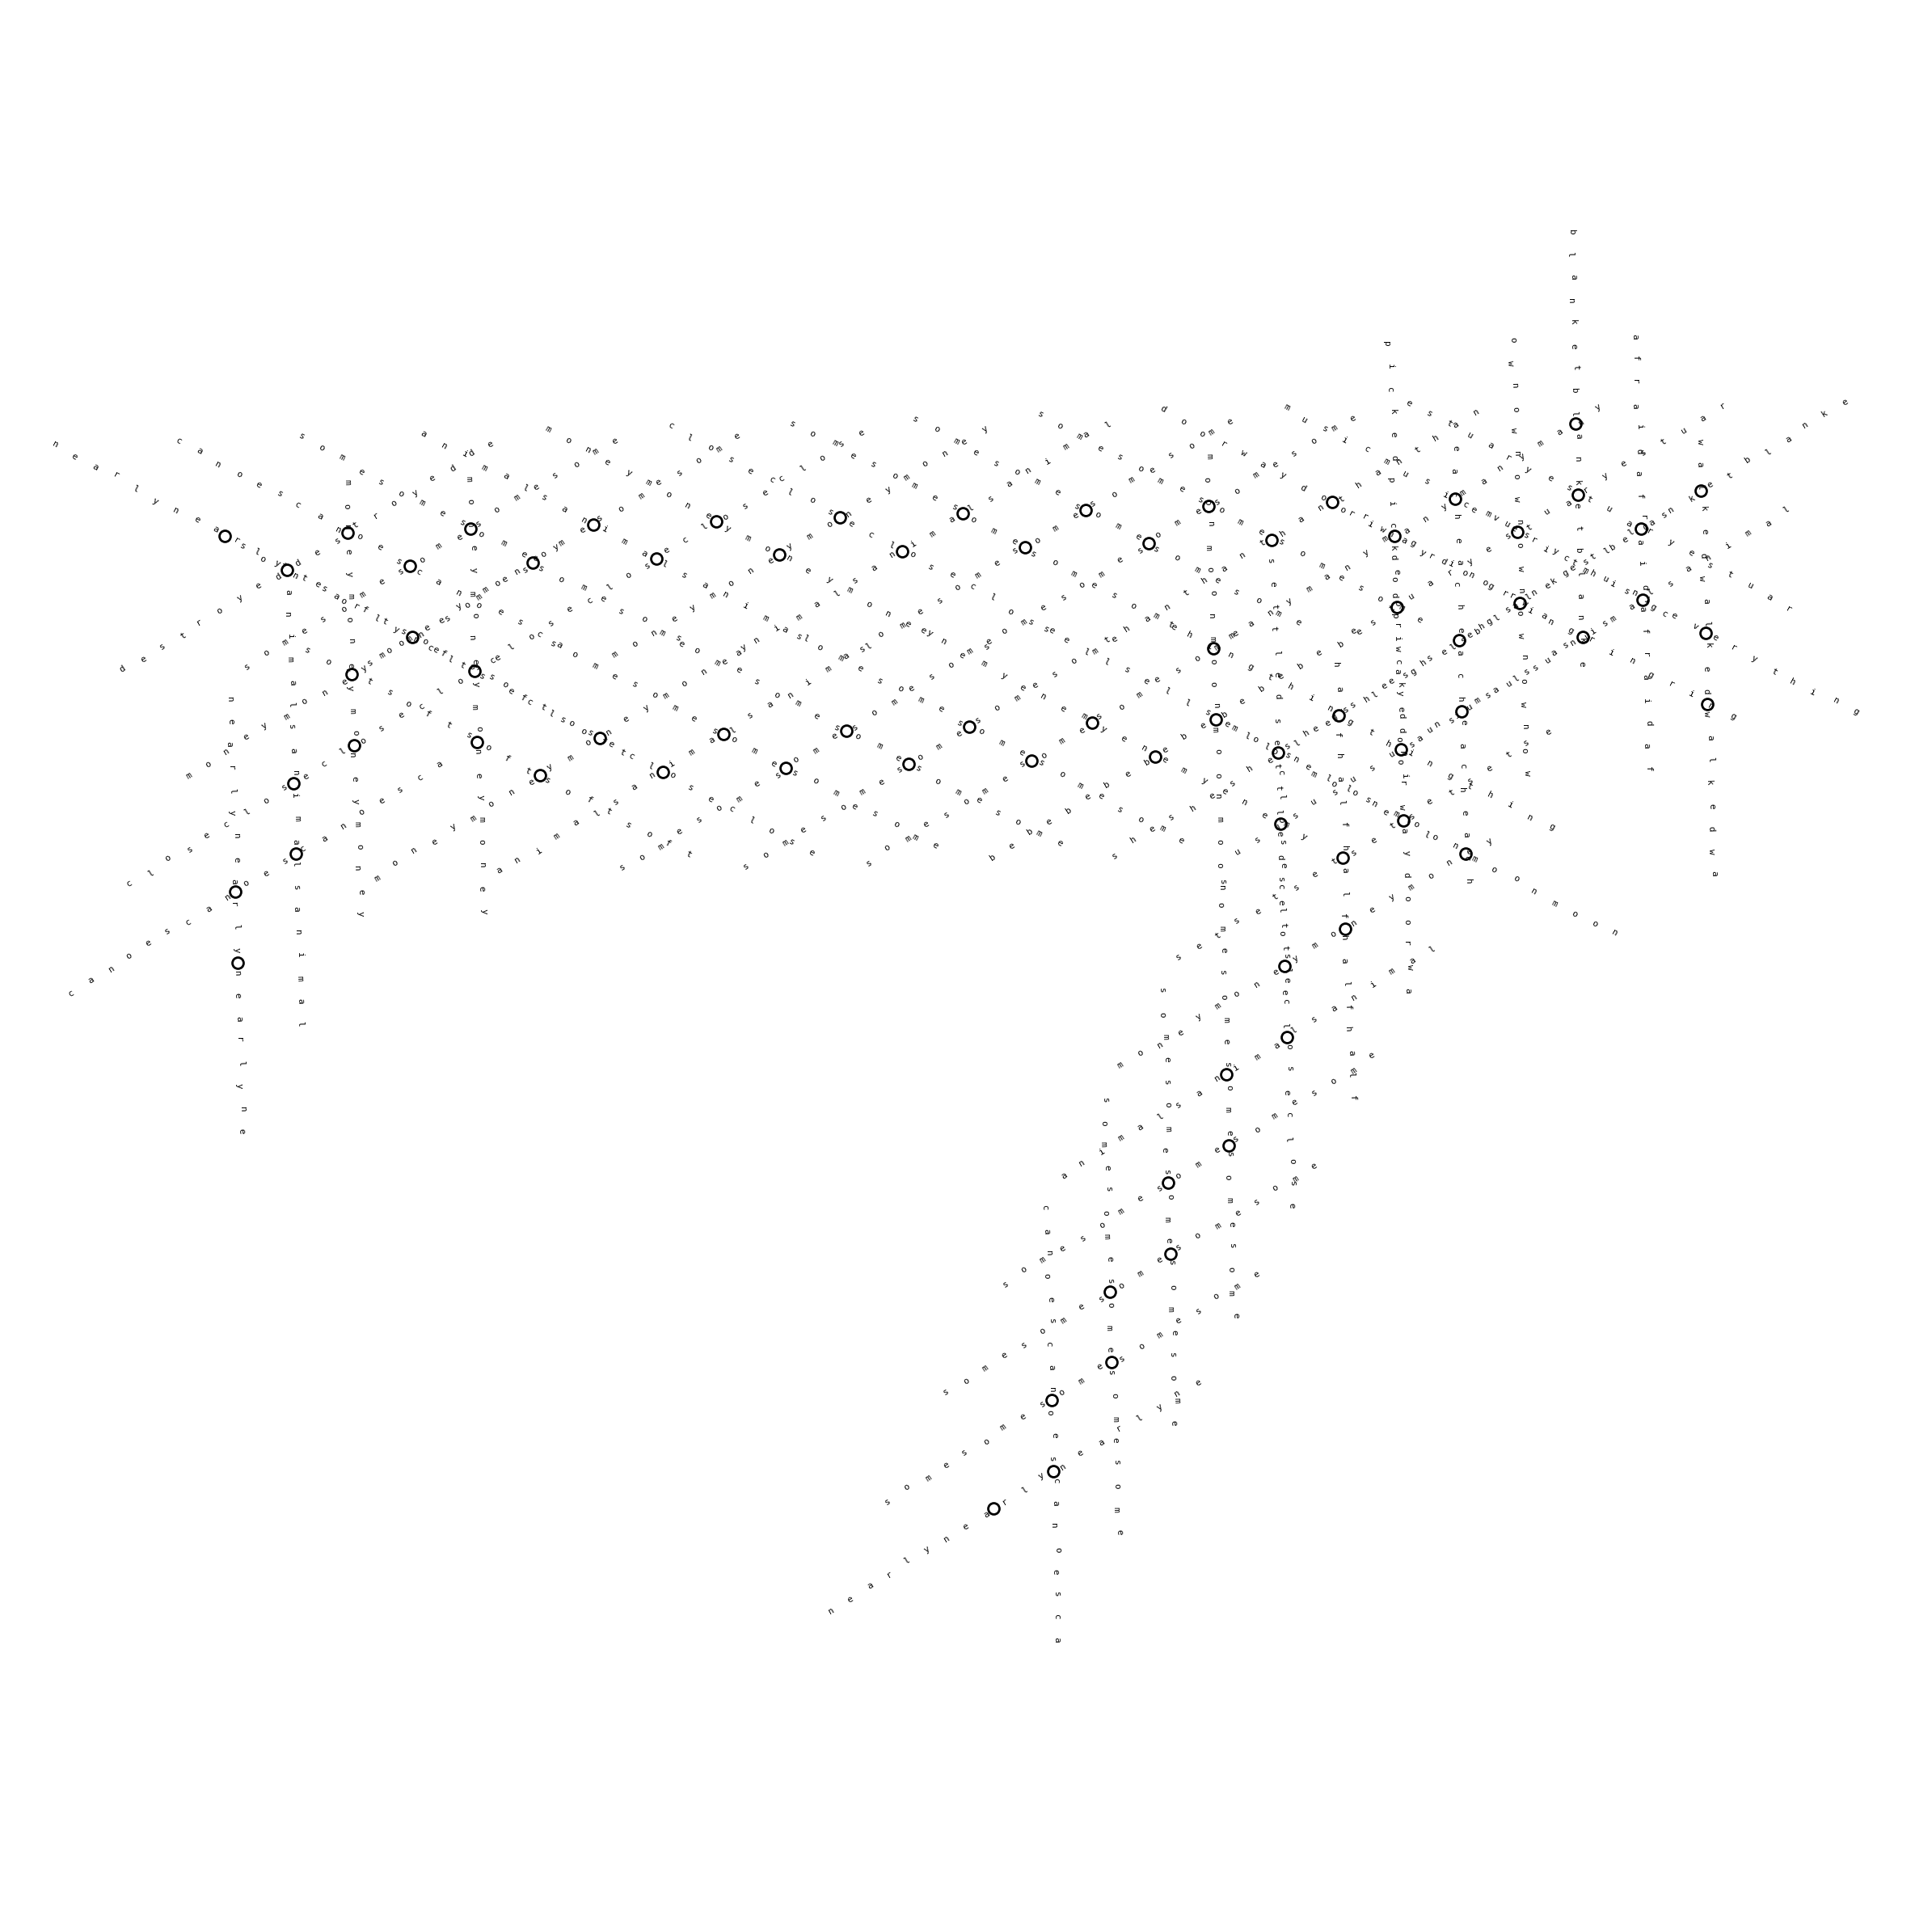

In [ ]:
index = 1

# 3. Repeated words (more dense)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    words_to_embed=row_to_words(fps_array[index]),
    target_length=20,
    spacing_char=None,  # Repetition mode
    font_size=8,
    vertical_jitter=0.05,
    letter_spacing_jitter=0.02
)
# plt.savefig('typewriter_repeated.png', dpi=300, bbox_inches='tight', facecolor='white')
